# K-1. Menyiapkan Lingkungan dan Memindahkan Perkakas dari Praktikum 1


Dilakukan impor terhadap modul sys, time, os, json, sqlite3, dan gc serta pustaka numpy dengan alias np, pandas dengan alias pd, dan psutil. Versi pustaka pandas, numpy, pyarrow, sklearn, requests, dan sqlalchemy diperiksa melalui *for loop* dengan fungsi bawaan \_\_import\_\_(), sedangkan blok *except* ImportError mencetak keterangan BELUM TERPASANG apabila pustaka tidak ditemukan. Google Drive disambungkan melalui drive.mount() pada /content/drive, lalu tiga direktori ditetapkan, yaitu DIR_MENTAH pada /content/lapisan_mentah untuk data mentah, DIR_KURASI pada /content/lapisan_terkurasi untuk data olahan, dan DIR_SIMPAN pada folder BigData/Praktikum3 di Drive untuk artefak. Ketiganya dibuat melalui os.makedirs() berparameter exist_ok=True sehingga sel dapat dijalankan berulang kali tanpa *error*.

Perkakas dari Praktikum 1 dipindahkan, yaitu objek proses dari psutil.Process(os.getpid()), list catatan, fungsi rss_mb() yang me-*return* pemakaian memori RSS dalam MB, dan fungsi ukur(label, fungsi) yang menjalankan fungsi tanpa argumen, mencatat durasi melalui time.perf_counter() serta selisih RSS ke catatan dengan kunci langkah, detik, dan delta_rss_mb, mencetak durasinya, lalu me-*return* hasil fungsi tersebut. Ditambahkan pula list lineage dan fungsi catat_sumber(nama, asal, jumlah_baris, keterangan) yang mencatat nama sumber, asal, waktu pengambilan dalam UTC dari pd.Timestamp.now("UTC"), jumlah baris, dan keterangan, lalu mencetak jumlah barisnya. Pemisahan lapisan mentah dan terkurasi mengikuti bagian G.1 modul agar data mentah tidak tertimpa hasil olahan.

In [ ]:
import sys, time, os, json, sqlite3, gc
import numpy as np, pandas as pd, psutil

for name in ["pandas", "numpy", "pyarrow", "sklearn", "requests", "sqlalchemy"]:
  try:
    mod = __import__(name)
    print(f"{name:11s}: {mod.__version__}")
  except ImportError:
    print(f"{name:11s}: BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"

for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
  os.makedirs(d, exist_ok=True)

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
  return proses.memory_info().rss / 1024 ** 2

def ukur(label, fungsi):
  m0, t0 = rss_mb(), time.perf_counter()
  hasil = fungsi()
  detik = time.perf_counter() - t0
  catatan.append({"langkah": label,
                  "detik": round(detik, 2),
                  "delta_rss_mb" : round(rss_mb() - m0, 1)})
  print(f"[{label}] {detik:.2f} s")
  return hasil

lineage = []
def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
  lineage.append({
      "sumber": nama, "asal": asal,
      "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
      "jumlah_baris": jumlah_baris, "keterangan": keterangan,
  })
  print(f"[lineage] {nama}: {jumlah_baris:,} baris")

pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
sklearn    : 1.6.1
requests   : 2.32.4
sqlalchemy : 2.0.52
Mounted at /content/drive


#K-2. Akuisisi 1 — Unduhan Berkala yang Tahan Gagal


Didefinisikan fungsi unduh_aman(url, tujuan, percobaan=3, jeda_awal=2) setelah impor modul requests dan shutil. Apabila berkas tujuan sudah ada dan berukuran lebih dari 0, fungsi mencetak keterangan *cache* dan langsung me-*return* jalur tersebut. Selain itu, *for loop* menjalankan paling banyak tiga percobaan, dan pada setiap percobaan berkas diminta melalui requests.get() berargumen stream=True dan timeout=60, diperiksa dengan raise_for_status(), lalu disalin ke berkas sementara berakhiran .part melalui shutil.copyfileobj(). Berkas berukuran 0 memicu IOError, sedangkan berkas yang lolos dipindahkan ke nama akhir dengan os.replace(). Setiap *exception* ditangani dengan mencetak nomor percobaan lalu menunggu jeda_awal dikali 2 pangkat i (*exponential backoff*), dan RuntimeError dilempar apabila semua percobaan gagal. Fungsi ini dipakai di dalam ukur() untuk mengunduh Parquet Januari 2023 dari URL_TRIP ke PATH_TRIP dan tabel zona dari URL_ZONA ke PATH_ZONA, ukuran kedua berkas dicetak dalam MB, 10 kolom pada KOLOM dibaca ke trip melalui pd.read_parquet(), tabel zona dibaca melalui pd.read_csv(), keduanya dicatat dengan catat_sumber(), dan lima baris pertama zona ditampilkan.

Keputusan pra-pemrosesan pada sel ini ada dua. Pertama, hanya 10 kolom pada KOLOM yang dimuat, mengikuti modul, termasuk PULocationID dan DOLocationID sebagai kunci *join* pada K-8, sedangkan kolom lain seperti VendorID, RatecodeID, extra, dan congestion_surcharge tidak dimuat sehingga komponen biaya tambahan tidak dapat dianalisis pada praktikum ini. Kedua, baris r.raw.decode_content = True ditambahkan di luar kode modul karena server mengirim taxi_zone_lookup.csv dengan kompresi gzip, sedangkan shutil.copyfileobj() menyalin byte mentah apa adanya, sehingga tanpa baris ini berkas tersimpan dalam bentuk gzip dan gagal dibaca pd.read_csv() dengan UnicodeDecodeError.

In [ ]:
import requests, shutil
def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
  """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
  if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
    print("Cache ditemukan: ", os.path.basename(tujuan))
    return tujuan
  sementara = tujuan + ".part"
  for i in range(percobaan):
    try:
      with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        r.raw.decode_content = True #file di download dalam bentuk .gzip, sehingga tidak bisa dibaca .read_csv
        with open(sementara, "wb") as f:
          shutil.copyfileobj(r.raw, f)
        if os.path.getsize(sementara) == 0:
          raise IOError("Berkas kosong")
        os.replace(sementara, tujuan) #atomik
        return tujuan
    except Exception as e:
      jeda = jeda_awal * (2 ** i) #exponential backoff
      print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
      time.sleep(jeda)
  raise RuntimeError(f"Gagal mengunduh setelah {percobaan} percobaan: {url}")

URL_TRIP = ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
URL_ZONA = ("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
  print(os.path.basename(pth), "->", round(os.path.getsize(pth) / 1024 ** 2, 2), "MB")

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
 "trip_distance", "PULocationID", "DOLocationID", "payment_type",
 "fare_amount", "tip_amount", "total_amount"]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(PATH_ZONA)

catat_sumber("trip", URL_TRIP,len(trip), "Parquet Bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")
zona.head()


[unduh trip] 0.30 s
[unduh zona] 0.04 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.01 MB
[baca trip] 0.87 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


#K-3. Akuisisi 2 — Memanggil API JSON

Konstanta API_CUACA ditetapkan bernilai alamat Open-Meteo Archive API, lalu didefinisikan fungsi ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3) yang menyusun parameter permintaan sebagai *dictionary*, yaitu koordinat, tanggal mulai dan selesai, variabel per jam temperature_2m dan precipitation, serta timezone America/New_York. Di dalam *for loop* sebanyak nilai percobaan, permintaan dikirim melalui requests.get() berargumen params dan timeout=60. Respons berstatus 200 di-*parse* dengan r.json() dan diperiksa keberadaan kunci hourly, dengan ValueError sebagai akibat apabila kunci itu tidak ada, lalu isinya di-*return* sebagai DataFrame. Status 429, 500, 502, dan 503 ditangani dengan menunggu 2 pangkat i detik sebelum mencoba lagi, status lain dihentikan melalui raise_for_status(), dan RuntimeError dilempar apabila semua percobaan habis. Fungsi dipanggil di dalam ukur() untuk rentang 2023-01-01 sampai 2023-01-31, kolom time dikonversi dengan pd.to_datetime(), kolom time, temperature_2m, dan precipitation diganti namanya menjadi jam_mulai, suhu_c, dan hujan_mm melalui rename(), lalu sumber dicatat dengan catat_sumber() dan lima baris pertama ditampilkan.


In [ ]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
  parameter={
      "latitude" : lat, "longitude": lon,
      "start_date": mulai, "end_date": selesai,
      "hourly": "temperature_2m,precipitation",
      "timezone": "America/New_York",
  }
  for i in range(percobaan):
    r = requests.get(API_CUACA, params=parameter, timeout=60)
    if r.status_code == 200:
      data = r.json()
      if "hourly" not in data:
        raise ValueError("kunci 'hourly' tidak ada respons")
      return pd.DataFrame(data["hourly"])
    if r.status_code in (429, 500, 502, 503):
      time.sleep(2 ** i)
      continue
    r.raise_for_status()
  raise RuntimeError("API cuaca tidak merespons dengan benar")

cuaca = ukur('ambil cuaca', lambda: ambil_cuaca("2023-01-01", "2023-01-31"))
cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={"time": "jam_mulai",
                              "temperature_2m" : "suhu_c",
                              "precipitation" : "hujan_mm"})
catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")
cuaca.head()


[ambil cuaca] 0.64 s
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


#K-4. Jalur Cadangan bila Internet Diblokir

Fungsi cuaca_sintesis(mulai, selesai, seed=7) ditulis dalam bentuk komentar sehingga tidak dieksekusi. Fungsi tersebut dirancang untuk membentuk deret jam melalui pd.date_range() berargumen freq="h" sampai pukul 23.00 pada tanggal selesai, lalu membangkitkan suhu_c dari distribusi normal berpusat 3 dengan simpangan baku 5 yang dibulatkan satu desimal dan hujan_mm dari distribusi gamma berparameter bentuk 0,4 dan skala 0,8 yang dibulatkan dua desimal melalui np.random.default_rng(seed). Jalur ini tidak diaktifkan karena pengambilan data cuaca melalui API pada K-3 berhasil, sehingga seluruh analisis memakai data cuaca nyata.

In [ ]:
# def cuaca_sintesis(mulai="2023-01-01", selesai="2023-01-31", seed=7):
#   jam = pd.date_range(mulai, pd.Timestamp(selesai) + pd.Timedelta("23h"), freq="h")
#   rng = np.random.default_rng(seed)
#   return pd.DataFrame({
#       "jam_mulai": jam,
#       "suhu_c" : np.round(rng.normal(3, 5, len(jam)), 1)
#       "hujan_mm": np.round(rng.gamma(0.4, 0.8, len(jam)), 2)
#   })

#K-5. Akuisisi 3 — Basis Data SQLite dengan Pemuatan Bertahap


Fungsi create_engine diimpor dari sqlalchemy, lalu *engine* SQLite dibentuk untuk PATH_DB, yaitu berkas operasional.db di DIR_MENTAH. DataFrame tarif_referensi disusun berisi kode payment_type 1 sampai 6, nama_pembayaran setiap kode, dan penanda kena_biaya_admin, kemudian ditulis sebagai tabel tarif_referensi melalui to_sql() berargumen if_exists="replace" dan index=False. Sebanyak 300.000 baris pertama trip ditulis sebagai tabel trip_operasional dengan chunksize=50_000, lalu nama tabel yang terbentuk dicetak dari sqlite_master. Kueri SQL menghitung jumlah perjalanan dan rata-rata total_amount per payment_type untuk baris dengan total_amount lebih dari 0, diurutkan dari jumlah terbesar, lalu hasilnya dibaca ke ringkas_db melalui pd.read_sql() dan dicetak. Kolom trip_distance kemudian dibaca bertahap melalui pd.read_sql() berargumen chunksize=50_000, dan jumlah barisnya diakumulasikan ke total_baris di dalam *for loop*. Terakhir, tarif_referensi dibaca ulang dari basis data dan dicatat dengan catat_sumber().

Keputusan pra-pemrosesan pada sel ini mengikuti modul. Tabel trip_operasional hanya berisi 300.000 baris pertama sebagai tiruan sistem operasional, sehingga ringkasan per payment_type dari kueri ini tidak mewakili seluruh bulan. Kode payment_type di luar 1 sampai 6 tidak memiliki pasangan di tarif_referensi, sehingga nama_pembayaran untuk kode tersebut akan kosong setelah *join* pada K-8.

In [ ]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type" : [1,2,3,4,5,6],
    "nama_pembayaran": ["Kartu Kredit", "Tunai", "Gratis",
                        "Sengketa", "Tidak diketahui", "Perjalanan Batal"],
    "kena_biaya_admin" : [1,0,0,0,0,0],
})

tarif_referensi.to_sql("tarif_referensi", engine, if_exists = "replace", index=False)
trip.head(300_000).to_sql(
    "trip_operasional", engine, if_exists="replace", index=False, chunksize=50_000
)

print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine
)["name"].to_list())

SQL = """
 SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
 FROM trip_operasional
 WHERE total_amount > 0
 GROUP BY payment_type
 ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional",
                          engine, chunksize=50_000):
  total_baris += len(bagian)
print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi),
             "tabel dimensi dari basis data operasional")



Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


#K-6. Profiling Kualitas Data pada Enam Dimensi

Kolom durasi_menit dibentuk dari selisih tpep_dropoff_datetime dan tpep_pickup_datetime yang dikonversi ke detik melalui dt.total_seconds() lalu dibagi 60. Didefinisikan fungsi profil_kolom(df) yang menjalankan *for loop* atas setiap kolom untuk mencatat nama kolom, tipe data, persentase nilai kosong yang dibulatkan tiga desimal, jumlah nilai unik melalui nunique(dropna=True), dan satu contoh nilai yang tidak kosong, lalu me-*return* hasilnya sebagai DataFrame profil. Batas periode AWAL dan AKHIR ditetapkan 2023-01-01 dan 2023-02-01, dan zona_sah dibentuk sebagai *set* LocationID dari tabel zona. Delapan aturan kualitas disusun di dalam *dictionary* aturan sebagai *boolean mask*, yaitu kelengkapan passenger_count, keunikan baris, jarak 0,01 sampai 100 mil, total_amount lebih dari 0, PULocationID terdaftar di zona_sah, durasi 1 sampai 180 menit, total_amount tidak lebih kecil dari fare_amount, dan waktu penjemputan di dalam Januari 2023. Jumlah lulus, gagal, dan persentase gagal setiap aturan dihimpun ke DataFrame laporan yang diurutkan menurun berdasarkan persen_gagal.

Keputusan pra-pemrosesan pada sel ini adalah penetapan ambang pada aturan kualitas, dan seluruh nilainya mengikuti modul. Rentang 0,01 sampai 100 mil dan 1 sampai 180 menit dipakai untuk menandai rekaman yang hampir pasti salah catat, bukan kebenaran mutlak, sedangkan between(AWAL, AKHIR) bersifat inklusif pada kedua ujungnya sehingga penjemputan tepat pukul 00.00 tanggal 1 Februari masih dianggap tepat waktu. Pada tahap ini belum ada baris yang dibuang karena laporan hanya mengukur, dan hasilnya menjadi dasar keputusan pembuangan pada K-8.

In [ ]:
trip["durasi_menit"] = (
(trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
.dt.total_seconds() / 60
)

def profil_kolom(df):
  baris = []
  for kol in df.columns:
    s = df[kol]
    baris.append({
        "kolom": kol, "tipe": str(s.dtype),
        "persen_hilang": round(100 * s.isna().mean(), 3),
        "nilai_unik": s.nunique(dropna=True),
        "contoh": s.dropna().iloc[0] if s.notna().any() else None,
    })
  return pd.DataFrame(baris)
profil = profil_kolom(trip)
display(profil)

AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])
aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0 - 100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1 - 180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu: dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}
laporan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()]).sort_values('persen_gagal', ascending=False)
laporan

,kolom,tipe,persen_hilang,nilai_unik,contoh
0,tpep_pickup_datetime,datetime64[us],0.000,1610975,2023-01-01 00:32:10
1,tpep_dropoff_datetime,datetime64[us],0.000,1611319,2023-01-01 00:40:36
2,passenger_count,float64,2.339,10,1.0
3,trip_distance,float64,0.000,4387,0.97
4,PULocationID,int64,0.000,257,161
5,DOLocationID,int64,0.000,261,141
6,payment_type,int64,0.000,5,2
7,fare_amount,float64,0.000,6873,9.3
8,tip_amount,float64,0.000,4036,0.0
9,total_amount,float64,0.000,15871,14.3


,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0 - 100 mil,3020816,45950,1.498
5,konsistensi: durasi 1 - 180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


#K-7. Nilai Hilang dan Duplikat

Konstanta KOL ditetapkan bernilai passenger_count dan kolomnya disimpan ke asli, lalu persentase nilai kosong kolom tersebut dicetak melalui isna().mean() yang dikalikan 100 dan dibulatkan tiga desimal. Kolom jam dibentuk dari tpep_pickup_datetime.dt.hour, kemudian empat strategi disusun di dalam *dictionary* strategi, yaitu pembuangan baris melalui dropna(), pengisian median melalui fillna(asli.median()), pengisian modus melalui fillna(asli.mode().iloc[0]), dan pengisian median per jam melalui fillna() atas groupby("jam")[KOL].transform("median"). Jumlah baris, rata-rata, median, dan simpangan baku hasil setiap strategi dihimpun ke DataFrame banding yang ditampilkan melalui display(). Jam yang memiliki nilai kosong disimpan ke jam_kosong dan median asli per jam disimpan ke median_jam melalui groupby(), lalu median, modus, dan daftar median_jam pada jam_kosong dicetak agar kesamaan hasil strategi pengisian dapat ditelusuri ke nilai pengisinya. Strategi terpilih kemudian diterapkan pada trip, yaitu kolom passenger_count_hilang bertipe int8 dibentuk dari isna(), nilai kosong diisi median per jam, dan sisa nilai kosong diisi median seluruh kolom. Duplikat diperiksa pada dua tingkat, yaitu duplikat penuh melalui duplicated() dan duplikat pada KUNCI yang berisi lima kolom, lalu baris duplikat pada KUNCI dibuang dengan drop_duplicates(subset=KUNCI, keep="first"), indeksnya diatur ulang melalui reset_index(drop=True), dan jumlah baris sebelum dan sesudahnya dicetak.

Keputusan pra-pemrosesan pada sel ini ada tiga. Pertama, nilai kosong passenger_count diisi median per jam, bukan dibuang, karena kekosongannya diduga bergantung pada variabel lain yang teramati sehingga tergolong MAR menurut bagian G.4 modul, dengan konsekuensi ragam kolom ini menyempit. Kedua, kolom penanda passenger_count_hilang dipertahankan agar baris hasil pengisian tetap dapat dibedakan apabila kekosongannya ternyata bersifat MNAR. Ketiga, duplikat didefinisikan pada lima kolom KUNCI dan kemunculan pertama dipertahankan, dengan risiko dua perjalanan berbeda yang memiliki waktu, zona, dan tarif identik ikut terhapus, sehingga jumlah duplikat dicetak sebelum penghapusan dilakukan.

In [ ]:
KOL = "passenger_count"
asli = trip[KOL]
print("persen hilang:", round(100 * asli.isna().mean(), 3))

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour
strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(trip.groupby("jam")[KOL].transform("median")),

}
banding = pd.DataFrame([
    {"strategi": nama, "n": len(s), "mean": round(s.mean(), 4),
     "median": s.median(), "std": round(s.std(), 4)}
    for nama, s in strategi.items()
])
display(banding)
jam_kosong = trip.loc[asli.isna(), "jam"].unique()
median_jam = asli.groupby(trip["jam"]).median()
print("median:", asli.median(), "| modus:", asli.mode().iloc[0],
      "| median per jam pada jam yang memiliki nilai kosong:", sorted(median_jam.loc[jam_kosong].unique().tolist()))

trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(trip.groupby("jam")[KOL].transform("median"))
trip[KOL] = trip[KOL].fillna(trip[KOL].median())

dup_penuh = trip.duplicated().sum()
KUNCI = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "PULocationID", "DOLocationID", "total_amount"]
dup_kunci = trip.duplicated(subset=KUNCI).sum()
print(f"duplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"{sebelum:,} -> {len(trip):,} baris")

persen hilang: 2.339


,strategi,n,mean,median,std
0,1_dibuang,2995023,1.3625,1.0,0.8961
1,2_isi_median,3066766,1.3541,1.0,0.8873
2,3_isi_modus,3066766,1.3541,1.0,0.8873
3,4_median_perjam,3066766,1.3541,1.0,0.8873


median: 1.0 | modus: 1.0 | median per jam pada jam yang memiliki nilai kosong: [1.0]
duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


#K-8. Outlier, Join dengan Tabel Referensi, dan Penggabungan Berbasis Waktu


Didefinisikan fungsi batas_iqr(s, k=1.5) yang me-*return* batas bawah dan batas atas dari kuartil pertama dan ketiga yang dikurangi dan ditambah k kali IQR, serta fungsi ringkas_outlier(df, kolom) yang untuk setiap kolom mencatat batas IQR, jumlah *outlier* menurut IQR, jumlah nilai dengan z-score mutlak lebih dari 3, dan persentil 99, lalu fungsi ini dipanggil untuk trip_distance, durasi_menit, dan total_amount. *Boolean mask* layak menggabungkan tiga syarat, yaitu trip_distance 0,01 sampai 100 mil, durasi_menit 1 sampai 180 menit, dan total_amount lebih dari 0, lalu baris yang lolos disalin ke bersih melalui loc[layak].copy(). Kolom tarif_ekstrem bertipe int8 menandai total_amount di atas batas atas IQR, sedangkan trip_distance_capped dibentuk dengan clip() pada persentil 99,5. Tiga *left join* dengan validate="many_to_one" kemudian dijalankan, yaitu zona pada PULocationID = LocationID yang menghasilkan borough_naik dan zona_naik, tarif_referensi pada payment_type yang menghasilkan nama_pembayaran, dan cuaca pada jam_mulai yang dibentuk dari tpep_pickup_datetime.dt.floor("h"). Jumlah baris sebelum dan sesudah penyaringan serta setiap *join*, keunikan kunci zona, jumlah zona tak dikenal, dan jumlah baris tanpa data cuaca dicetak.

Keputusan pra-pemrosesan pada sel ini ada empat. Pertama, baris di luar syarat layak dibuang karena jarak, durasi, dan tarif tersebut hampir pasti salah catat, dengan konsekuensi perjalanan sah yang berdurasi lebih dari 180 menit ikut terbuang. Kedua, tarif mahal hanya ditandai melalui tarif_ekstrem dengan k = 1,5 sesuai bagian G.5 modul, bukan dibuang, karena *outlier* tarif dapat berupa kenyataan bisnis seperti perjalanan bandara. Ketiga, *winsorizing* pada persentil 99,5 hanya diterapkan pada kolom turunan trip_distance_capped agar nilai asli trip_distance tetap utuh. Keempat, ketiga *join* memakai *left join* dengan validate="many_to_one" sesuai bagian G.6 modul, sehingga tidak ada transaksi yang hilang dan penggandaan baris menghentikan proses dengan MergeError.

In [ ]:
def batas_iqr(s, k=1.5):
  q1, q3 = s.quantile([0.25, 0.75])
  iqr = q3 - q1
  return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
  hasil = []
  for kol in kolom:
    s = df[kol].dropna()
    lo, hi = batas_iqr(s)
    z = (s - s.mean()) / s.std()
    hasil.append({
        "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
        "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
        "outlier_z3": int((z.abs() > 3).sum()), "p99": round(s.quantile(.99), 2),
    })
  return pd.DataFrame(hasil)
display(ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"]))

layak = (trip["trip_distance"].between(.01, 100)
        & trip["durasi_menit"].between(1, 180) & (trip["total_amount"] > 0))
bersih = trip.loc[layak].copy()

lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

batas_atas = bersih["trip_distance"].quantile(.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)

print(f"{len(trip):,} -> {len(bersih):,} baris "
      f"({100 * (1-len(bersih)/len(trip)):.2f}% dibuang)")


print("kunci zona unik?", zona["LocationID"].is_unique)
n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
        .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one"
)
bersih = bersih.drop(columns="LocationID")
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tak dikenal:", bersih["zona_naik"].isna().sum())

bersih = bersih.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                      on="payment_type", how="left", validate="many_to_one")

bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0 = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())

,kolom,batas_bawah,batas_atas,outlier_iqr,outlier_z3,p99
0,trip_distance,-2.35,6.74,390244,67,20.06
1,durasi_menit,-9.66,35.08,170615,3175,57.25
2,total_amount,-4.55,48.65,371616,87248,101.94


3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


## Grafik Distribusi total_amount Sebelum dan Sesudah Pra-pemrosesan

Kolom total_amount dari data mentah dibaca ulang dari PATH_TRIP ke tarif_mentah, sedangkan tarif_bersih diambil dari bersih hasil K-8. Keduanya digambar sebagai dua histogram berdampingan dengan batas bin yang sama, sumbu-x dan sumbu-y yang dibagi, sumbu-y logaritmik, dan garis putus-putus pada nilai 0. Judul setiap panel memuat jumlah baris dan jumlah nilai di luar RENTANG_TARIF. Gambar disimpan sebagai histogram_total_amount.png di DIR_SIMPAN, lalu ringkasan statistik kedua data ditampilkan.

Keputusan visualisasi pada sel ini ada dua. Pertama, sumbu-x dibatasi -50 sampai 150 USD dengan lebar bin 2 USD agar kedua histogram memakai sumbu-x yang sama, dengan konsekuensi nilai ekstrem di luar rentang tidak tergambar, sehingga jumlahnya dicetak pada judul panel. Kedua, sumbu-y dibuat logaritmik karena nilai yang kurang dari atau sama dengan 0 hanya 0,84% data, sehingga pada skala linear perubahan ekor kiri tidak akan terlihat.

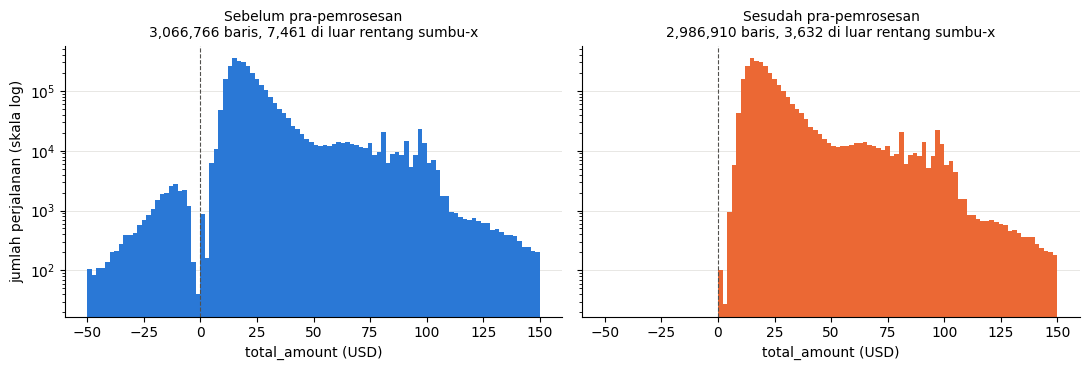

,sebelum,sesudah
count,3066766.00,2986910.00
mean,27.02,27.33
std,22.16,21.15
min,-751.00,1.00
50%,20.16,20.16
99%,101.94,101.38
max,1169.40,614.45
nilai <= 0,25772.00,0.00
skewness,2.83,3.03


In [ ]:
import matplotlib.pyplot as plt

RENTANG_TARIF = (-50, 150)
LEBAR_BIN = 2
WARNA = {"sebelum": "#2a78d6", "sesudah": "#eb6834"}

tarif_mentah = pd.read_parquet(PATH_TRIP, columns=["total_amount"])["total_amount"]
tarif_bersih = bersih["total_amount"]
batas_bin = np.arange(RENTANG_TARIF[0], RENTANG_TARIF[1] + LEBAR_BIN, LEBAR_BIN)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True, sharey=True)
panel = [("Sebelum pra-pemrosesan", tarif_mentah, WARNA["sebelum"]),
         ("Sesudah pra-pemrosesan", tarif_bersih, WARNA["sesudah"])]
for a, (judul, data, warna) in zip(ax, panel):
  di_luar = ((data < RENTANG_TARIF[0]) | (data > RENTANG_TARIF[1])).sum()
  a.hist(data, bins=batas_bin, color=warna)
  a.axvline(0, color="#52514e", linewidth=0.8, linestyle="--")
  a.set_yscale("log")
  a.set_title(f"{judul}\n{len(data):,} baris, {di_luar:,} di luar rentang sumbu-x", fontsize=10)
  a.set_xlabel("total_amount (USD)")
  a.grid(axis="y", color="#e4e3df", linewidth=0.6)
  a.set_axisbelow(True)
  for sisi in ("top", "right"):
    a.spines[sisi].set_visible(False)
ax[0].set_ylabel("jumlah perjalanan (skala log)")
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/histogram_total_amount.png", dpi=200)
plt.show()

ringkas = pd.DataFrame({
    "sebelum": tarif_mentah.describe(percentiles=[.5, .99]),
    "sesudah": tarif_bersih.describe(percentiles=[.5, .99]),
})
ringkas.loc["nilai <= 0"] = [(tarif_mentah <= 0).sum(), (tarif_bersih <= 0).sum()]
ringkas.loc["skewness"] = [tarif_mentah.skew(), tarif_bersih.skew()]
display(ringkas.round(2))

#K-9. Rekayasa Fitur: Encoding dan Scaling Tanpa Kebocoran

Lima kolom turunan dibentuk pada bersih, yaitu hari_minggu dari dt.dayofweek, akhir_pekan bertipe int8 untuk hari bernilai 5 ke atas, kecepatan_mph dari trip_distance dibagi durasi dalam jam yang dibulatkan dua desimal, tarif_per_mil dari total_amount dibagi trip_distance yang dibulatkan tiga desimal, dan hujan bertipe int8 untuk hujan_mm lebih dari 0,1 setelah nilai kosong diisi 0. Fungsi train_test_split, StandardScaler, dan OneHotEncoder diimpor dari sklearn, lalu FITUR_NUM berisi trip_distance_capped, durasi_menit, dan suhu_c, sedangkan FITUR_KAT berisi nama_pembayaran dan borough_naik. Baris yang kosong pada kedua daftar fitur dibuang melalui dropna(), kemudian diambil sampel sebanyak min(200_000, len(bersih)) baris dengan random_state=42 dan dibagi menjadi latih dan uji dengan test_size=.2. StandardScaler di-*fit* hanya pada latih lalu dipakai untuk mentransformasi latih dan uji, dan rata-rata kedua hasil dicetak. OneHotEncoder berargumen handle_unknown="ignore" dan sparse_output=False di-*fit* pada kategori latih, lalu jumlah kolom hasil *one-hot encoding* dan enam nama kolom pertamanya dicetak.

Keputusan pra-pemrosesan pada sel ini ada tiga. Pertama, statistik *scaler* dan daftar kategori *encoder* hanya dipelajari dari data latih untuk mencegah *data leakage* sesuai bagian G.7 modul, sehingga rata-rata data uji tidak harus bernilai nol. Kedua, baris dengan fitur kosong dibuang hanya dari sampel pemodelan, bukan dari bersih, dan sampel dibatasi 200.000 baris dengan random_state=42 agar hasilnya dapat diulang. Ketiga, jam tanpa data cuaca dianggap tidak hujan melalui fillna(0), dengan risiko sebagian jam hujan tercatat sebagai jam kering.

In [ ]:
bersih["hari_minggu"] = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"] = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"] / bersih["trip_distance"]).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > .1).astype("int8")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42
)
latih, uji = train_test_split(contoh, test_size=.2, random_state=42)

skala = StandardScaler().fit(latih[FITUR_NUM])
latih_num = skala.transform(latih[FITUR_NUM])
uji_num = skala.transform(uji[FITUR_NUM])
print("mean latih (harus ~0):", latih_num.mean(axis=0).round(3))
print("mean uji (tidak harus 0):", uji_num.mean(axis=0).round(3))

enc = OneHotEncoder(handle_unknown = "ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])
print("jumlah kolom hasil one-hot:", latih_kat.shape[1])
print("nama kolom:", enc.get_feature_names_out()[:6], "...")

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu Kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


#K-10. Membungkus Jadi Pipeline, Memvalidasi, dan Menyimpan Berpartisi

*Dictionary* KONTRAK menetapkan tipe data wajib untuk enam kolom, lalu fungsi validasi(df, kontrak=KONTRAK) memeriksa keberadaan setiap kolom, kesesuaian awalan tipe datanya, DataFrame yang kosong, dan duplikat pada KUNCI, kemudian melempar AssertionError berisi daftar masalah atau mencetak jumlah baris dan kolom apabila lulus. Fungsi ini langsung dijalankan pada bersih. Fungsi pipeline(path_trip, path_zona, df_cuaca, df_tarif) merangkum K-2 sampai K-8, yaitu membaca KOLOM dari Parquet dan tabel zona, membentuk durasi_menit dan jam, mengisi passenger_count dengan median per jam, membuang duplikat pada KUNCI, menyaring baris dengan syarat yang sama seperti layak, menjalankan tiga *left join* dengan validate="many_to_one", lalu me-*return* hasil validasi(). Hasilnya disimpan ke hasil melalui ukur() dan ditambahkan kolom tanggal, lalu data ditulis ke OUT_SEMENTARA dengan partition_cols=["borough_naik"], folder OUT lama dihapus dengan shutil.rmtree(), dan OUT_SEMENTARA dipindahkan ke OUT melalui os.replace(). pipeline() dijalankan ulang untuk membandingkan jumlah baris, kemudian laporan_kualitas.csv, lineage.csv, dan pengukuran_kinerja.csv disimpan ke DIR_SIMPAN dan folder OUT diarsipkan menjadi trips_bersih.zip.

Keputusan pra-pemrosesan pada sel ini ada tiga. Pertama, data dipartisi menurut borough_naik karena kolom ini memiliki sedikit nilai dan sering dipakai sebagai filter, sehingga mendukung *partition pruning*. Kedua, penulisan melalui folder sementara, penghapusan OUT, dan os.replace() ditambahkan di luar kode modul karena to_parquet() berpartisi tidak menimpa berkas lama, sehingga tanpa langkah ini setiap eksekusi ulang menambah berkas baru dan jumlah baris di disk berlipat, bertentangan dengan idempotensi pada bagian G.8. Ketiga, pipeline() mengisi passenger_count tanpa kolom penanda dan tanpa pengisian median seluruh kolom seperti K-7, sehingga baris hasil imputasi tidak dapat dibedakan pada hasil akhir.

In [ ]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]", "trip_distance": "float64",
    "durasi_menit": "float64", "total_amount":"float64",
    "borough_naik": "object", "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
  masalah = []
  for kol, tipe in kontrak.items():
    if kol not in df.columns:
      masalah.append(f"kolom hilang: {kol}")
    elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
      masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")
  if df.empty:
    masalah.append("DataFrame kosong")
  if len(df) != len(df.drop_duplicates(subset=KUNCI)):
    masalah.append("masih ada duplikat pada kunci")
  if masalah:
    raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
  print(f"Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
  return df

validasi(bersih)

def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
  """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
  df = pd.read_parquet(path_trip, columns=KOLOM)
  z = pd.read_csv(path_zona)
  df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60)
  df["jam"] = df["tpep_pickup_datetime"].dt.hour
  df["passenger_count"] = df["passenger_count"].fillna(
      df.groupby("jam")["passenger_count"].transform("median")
  )
  df = df.drop_duplicates(subset=KUNCI)
  df = df[df["trip_distance"].between(.01, 100)
          & df["durasi_menit"].between(1, 180)
          & (df["total_amount"] > 0)]
  df = (df.merge(z[["LocationID", "Borough"]]
                 .rename(columns={"Borough": "borough_naik"}),
                 left_on="PULocationID", right_on="LocationID",
                 how="left", validate="many_to_one")
                .drop(columns="LocationID")
                .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                       on="payment_type", how="left", validate="many_to_one"))
  df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
  df = df.merge(df_cuaca, on="jam_mulai", how = "left", validate="many_to_one")
  return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))

OUT = os.path.join(DIR_KURASI, "trips_bersih")
OUT_SEMENTARA = OUT + "_sementara"
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype("str")
shutil.rmtree(OUT_SEMENTARA, ignore_errors=True)
ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT_SEMENTARA, partition_cols=["borough_naik"], index=False
))
shutil.rmtree(OUT, ignore_errors=True)
os.replace(OUT_SEMENTARA, OUT)
print("partisi yang terbentuk:", sorted(os.listdir(OUT))[:5], "...")

ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("idempoten?", len(ulang) == len(hasil))

laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)


Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 6.39 s
[tulis parquet berpartisi] 3.15 s
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

## Rincian Waktu Setiap Tahap Pipeline

Didefinisikan fungsi ukur_tahap(path_trip, path_zona, df_cuaca, df_tarif) yang menjalankan tahap yang sama dengan pipeline() secara berurutan, dan setiap tahap dibungkus ukur() dengan label berawalan "tahap: " sehingga durasinya tercatat pada catatan. Tahap tersebut adalah pembacaan KOLOM dari Parquet, pembentukan durasi_menit dan jam beserta pengisian passenger_count dengan median per jam melalui fungsi dalam siapkan(d), penghapusan duplikat pada KUNCI, filter kelayakan dengan syarat yang sama seperti K-8, *left join* zona pada PULocationID = LocationID, *left join* tarif_referensi pada payment_type, *left join* cuaca pada jam_mulai yang dibentuk dari dt.floor("h"), dan validasi(). Ketiga *join* memakai validate="many_to_one". Fungsi dijalankan dengan argumen yang sama seperti K-10 dan hasilnya disimpan ke hasil_tahap. Catatan berlabel tahap diambil ke DataFrame rincian melalui drop_duplicates("langkah", keep="last"), lalu kolom persen dibentuk dari detik setiap tahap dibagi total detik yang dibulatkan satu desimal. Total detik, jumlah detik tiga *join* beserta persentasenya, detik pembacaan, rasio *join* terhadap pembacaan, dan kesamaan jumlah baris hasil_tahap dengan hasil dicetak, lalu hasil_tahap dihapus melalui del dan gc.collect() sebelum rincian ditampilkan.

Keputusan pengukuran pada sel ini ada tiga. Pertama, waktu diukur pada salinan alur di dalam ukur_tahap(), bukan dengan mengubah pipeline(), agar fungsi yang dipakai Latihan 6 dan Tugas 1 tetap sama dengan K-10, dengan konsekuensi data Januari diproses sekali lagi dan jumlah detik seluruh tahap dapat berbeda dari pipeline penuh karena kondisi memori saat sel ini dijalankan berbeda. Kedua, pembacaan taxi_zone_lookup.csv tidak dibungkus ukur() karena hanya berisi 265 baris, sedangkan pembentukan jam_mulai dimasukkan ke tahap *join* cuaca, sehingga waktu *join* cuaca sedikit lebih besar daripada waktu merge() saja. Ketiga, catatan tahap diambil dengan keep="last" agar sel dapat dijalankan ulang tanpa menggandakan baris rincian, dengan konsekuensi pengukuran sebelumnya tetap tersimpan di catatan dan ikut tertulis ke pengukuran_kinerja.csv pada Tugas 6.

In [ ]:
def ukur_tahap(path_trip, path_zona, df_cuaca, df_tarif):
  df = ukur("tahap: baca parquet", lambda: pd.read_parquet(path_trip, columns=KOLOM))
  z = pd.read_csv(path_zona)

  def siapkan(d):
    d["durasi_menit"] = (d["tpep_dropoff_datetime"] - d["tpep_pickup_datetime"]).dt.total_seconds() / 60
    d["jam"] = d["tpep_pickup_datetime"].dt.hour
    d["passenger_count"] = d["passenger_count"].fillna(d.groupby("jam")["passenger_count"].transform("median"))
    return d

  df = ukur("tahap: kolom + imputasi", lambda: siapkan(df))
  df = ukur("tahap: hapus duplikat", lambda: df.drop_duplicates(subset=KUNCI))
  df = ukur("tahap: filter kelayakan", lambda: df[df["trip_distance"].between(.01, 100)
                                               & df["durasi_menit"].between(1, 180)
                                               & (df["total_amount"] > 0)])
  df = ukur("tahap: join zona", lambda: df.merge(
      z[["LocationID", "Borough"]].rename(columns={"Borough": "borough_naik"}),
      left_on="PULocationID", right_on="LocationID", how="left", validate="many_to_one"
  ).drop(columns="LocationID"))
  df = ukur("tahap: join tarif", lambda: df.merge(
      df_tarif[["payment_type", "nama_pembayaran"]], on="payment_type", how="left", validate="many_to_one"))
  df = ukur("tahap: join cuaca", lambda: df.assign(jam_mulai=df["tpep_pickup_datetime"].dt.floor("h"))
                                          .merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one"))
  return ukur("tahap: validasi", lambda: validasi(df))

hasil_tahap = ukur_tahap(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)

rincian = (pd.DataFrame([c for c in catatan if c["langkah"].startswith("tahap: ")])
           .drop_duplicates("langkah", keep="last").reset_index(drop=True))
rincian["persen"] = (100 * rincian["detik"] / rincian["detik"].sum()).round(1)
detik_join = rincian.loc[rincian["langkah"].str.startswith("tahap: join"), "detik"].sum()
detik_baca = rincian.loc[rincian["langkah"] == "tahap: baca parquet", "detik"].iloc[0]
print(f"total tahap: {rincian['detik'].sum():.2f} s | tiga join: {detik_join:.2f} s "
      f"({100 * detik_join / rincian['detik'].sum():.1f}%) | baca: {detik_baca:.2f} s "
      f"| join/baca: {detik_join / detik_baca:.1f} kali")
print("jumlah baris sama dengan hasil?", len(hasil_tahap) == len(hasil))
del hasil_tahap
gc.collect()
display(rincian)

[tahap: baca parquet] 0.68 s
[tahap: kolom + imputasi] 0.23 s
[tahap: hapus duplikat] 1.34 s
[tahap: filter kelayakan] 0.21 s
[tahap: join zona] 0.66 s
[tahap: join tarif] 0.38 s
[tahap: join cuaca] 1.02 s
Validasi lulus: 2,986,910 baris x 17 kolom
[tahap: validasi] 1.43 s
total tahap: 5.95 s | tiga join: 2.06 s (34.6%) | baca: 0.68 s | join/baca: 3.0 kali
jumlah baris sama dengan hasil? True


,langkah,detik,delta_rss_mb,persen
0,tahap: baca parquet,0.68,245.5,11.4
1,tahap: kolom + imputasi,0.23,0.0,3.9
2,tahap: hapus duplikat,1.34,163.8,22.5
3,tahap: filter kelayakan,0.21,159.5,3.5
4,tahap: join zona,0.66,295.0,11.1
5,tahap: join tarif,0.38,136.7,6.4
6,tahap: join cuaca,1.02,364.6,17.1
7,tahap: validasi,1.43,0.0,24.0


#K-11. Pra-pemrosesan Setara dengan PySpark (Tambahan)

PySpark versi 3.5.1 dipasang melalui pip, lalu SparkSession dan modul functions dengan alias F diimpor. SparkSession dibangun melalui pola *builder* dengan appName("BD-P03"), master("local[\*]"), memori *driver* 4 GB, delapan partisi *shuffle*, spark.sql.parquet.inferTimestampNTZ.enabled bernilai false, dan spark.sql.session.timeZone bernilai UTC, kemudian tingkat log diturunkan ke WARN. Berkas Parquet dibaca sebagai sdf dengan kolom pada KOLOM, dan tabel zona berisi LocationID dan Borough diubah menjadi szona melalui createDataFrame(). Rangkaian transformasi sbersih membentuk durasi_menit dari selisih kedua kolom waktu yang di-*cast* ke long lalu dibagi 60, menerapkan tiga filter() dengan syarat yang sama seperti pandas, membuang duplikat pada lima kolom kunci melalui dropDuplicates(), lalu menggabungkan szona melalui *left join* dengan F.broadcast(). Jumlah baris dihitung dengan count() di dalam ukur(), jumlah perjalanan per Borough ditampilkan melalui groupBy() dan show(10, False), hasil ditulis ke /content/lapisan_terkurasi/trips_spark dengan mode("overwrite") dan partitionBy("Borough"), lalu rencana eksekusi ditampilkan dengan explain() dan sesi ditutup dengan spark.stop().

Keputusan pra-pemrosesan pada sel ini ada tiga. Pertama, dua konfigurasi waktu ditambahkan di luar kode modul karena kolom waktu Parquet TLC terbaca sebagai TIMESTAMP_NTZ yang tidak dapat di-*cast* ke long pada Spark 3.5, sehingga kolom waktu dibaca sebagai TIMESTAMP dengan acuan UTC dan durasi_menit sama dengan hasil pandas. Kedua, tabel zona di-*broadcast* karena ukurannya kecil, sehingga *join* tidak memerlukan *shuffle*. Ketiga, dropDuplicates() dijalankan setelah filter, berbeda dengan pandas yang membuang duplikat sebelum penyaringan, dan nilai Borough yang kosong tidak diisi sehingga terbaca sebagai teks NaN, sehingga selisih jumlah baris atau kelompok terhadap K-8 dapat berasal dari kedua perbedaan tersebut.

In [ ]:
!pip install -q pyspark==3.5.1

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("BD-P03").master("local[*]")
        .config("spark.driver.memory", "4g")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.sql.parquet.inferTimestampNTZ.enabled", "false")
        .config("spark.sql.session.timeZone", "UTC") #kolom waktu di Parquet TLC disimpan tanpa zona waktu. Spark 3.4 ke atas membaca kolom seperti itu sebagai TIMESTAMP_NTZ, dan Spark 3.5 tidak mengizinkan tipe itu di-cast ke long (BIGINT). Kode modul memakai .cast("long"), jadi error
        .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (sdf
           .withColumn("durasi_menit",
                       (F.col("tpep_dropoff_datetime").cast("long")
                       - F.col("tpep_pickup_datetime").cast("long"))/ 60)
           .filter(F.col("trip_distance").between(.01, 100))
           .filter(F.col("durasi_menit").between(1, 180))
           .filter(F.col("total_amount") > 0)
           .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                            "PULocationID", "DOLocationID", "total_amount"])
           .join(F.broadcast(szona),
                 sdf.PULocationID == szona.LocationID, "left")
           .drop("LocationID"))
ukur("spark: hitung baris bersih", lambda: sbersih.count())
sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

sbersih.write.mode("overwrite").partitionBy("Borough") \
      .parquet("/content/lapisan_terkurasi/trips_spark")
sbersih.explain()
spark.stop()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 16.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[spark: hitung baris bersih] 14.76 s
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#245, trip_distance#247, PULocationID#7L, DOLocatio

#P. Studi Kasus
## Kasus: menyiapkan data untuk tim penetapan harga dinamis
Tim pricing ingin menguji dugaan bahwa tarif per mil meningkat pada jam hujan di borough tertentu.
Mereka meminta satu tabel analitik siap pakai dengan tingkat rincian satu baris per borough per jam,
memuat: jumlah perjalanan, rata-rata tarif per mil, rata-rata kecepatan, suhu, dan penanda hujan. Syarat
mereka: tabel harus bisa diperbarui otomatis setiap bulan, dan setiap angka harus bisa ditelusuri sampai
ke sumbernya. Mereka juga meminta Anda menyatakan secara eksplisit di bagian mana hasil ini tidak
boleh dipercaya begitu saja.

DataFrame bersih diberi kolom jam_mulai dari tpep_pickup_datetime.dt.floor("h") melalui assign(), lalu dikelompokkan per borough_naik dan jam_mulai dengan groupby() berargumen observed=True. Agregasi *named aggregation* menghasilkan lima kolom, yaitu jumlah_perjalanan dari size pada total_amount, rata_tarif_per_mil dan rata_kecepatan dari median tarif_per_mil dan kecepatan_mph, suhu_c dari nilai pertama suhu_c, dan hujan dari nilai maksimum penanda hujan, kemudian indeks dikembalikan menjadi kolom melalui reset_index(). Kelompok dengan jumlah_perjalanan kurang dari 30 dibuang, lalu median rata_tarif_per_mil per borough_naik dan hujan dicetak dalam bentuk tabel melalui unstack().

Keputusan pra-pemrosesan pada sel ini ada tiga. Pertama, tingkat rincian ditetapkan satu baris per borough per jam sesuai permintaan tim pricing. Kedua, median dipakai alih-alih rerata untuk tarif per mil dan kecepatan karena distribusinya miring ke kanan, meskipun nama kolomnya tetap diawali rata mengikuti modul. Ketiga, kelompok dengan kurang dari 30 perjalanan dibuang karena median dari kelompok sekecil itu tidak stabil, dengan konsekuensi borough bervolume kecil dapat tidak terwakili pada tabel.

In [ ]:
tabel_analitik = (bersih
                  .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
                  .groupby(["borough_naik", "jam_mulai"], observed=True)
                  .agg(jumlah_perjalanan=("total_amount", "size"),
                       rata_tarif_per_mil=("tarif_per_mil", "median"),
                       rata_kecepatan=("kecepatan_mph", "median"),
                       suhu_c = ("suhu_c", "first"), hujan=("hujan", "max"))
                  .reset_index())

tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"] >= 30]

print(tabel_analitik
      .groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"]
      .median().unstack())


hujan               0        1
borough_naik                  
Brooklyn       6.9430   7.6550
Manhattan     10.5270  11.4000
Queens         5.4530   5.6365
Unknown        8.7255   9.8860


Konstanta PATH_ANALITIK ditetapkan pada DIR_SIMPAN dengan nama tabel_analitik.parquet, lalu tabel_analitik disimpan melalui to_parquet() berargumen index=False dan jumlah barisnya dicetak. DataFrame banding_hujan dibentuk dengan mengelompokkan tabel_analitik per borough_naik dan hujan untuk menghitung jumlah jam melalui size dan median rata_tarif_per_mil, lalu hasilnya disusun berdampingan melalui unstack("hujan") dan kolomnya diberi nama jam_kering, jam_hujan, tarif_per_mil_kering, dan tarif_per_mil_hujan. Kolom selisih_persen menyatakan selisih tarif per mil jam hujan terhadap jam kering dalam persen yang dibulatkan dua desimal.

Keputusan pra-pemrosesan pada sel ini adalah pembandingan memakai median dari median per jam, sehingga setiap jam berbobot sama tanpa memperhatikan jumlah perjalanannya. Jumlah jam hujan dan jam kering ikut ditampilkan agar selisih yang hanya didukung sedikit jam hujan dapat dikenali.

In [ ]:
PATH_ANALITIK = os.path.join(DIR_SIMPAN, "tabel_analitik.parquet")

tabel_analitik.to_parquet(PATH_ANALITIK, index=False)
print(f"tabel analitik: {len(tabel_analitik):,} baris -> {os.path.basename(PATH_ANALITIK)}")

banding_hujan = (tabel_analitik
                 .groupby(["borough_naik", "hujan"], observed=True)
                 .agg(jumlah_jam=("jam_mulai", "size"),
                      median_tarif_per_mil=("rata_tarif_per_mil", "median"))
                 .unstack("hujan"))
banding_hujan.columns = ["jam_kering", "jam_hujan", "tarif_per_mil_kering", "tarif_per_mil_hujan"]
banding_hujan["selisih_persen"] = (100 * (banding_hujan["tarif_per_mil_hujan"]
                                          / banding_hujan["tarif_per_mil_kering"] - 1)).round(2)
banding_hujan

tabel analitik: 2,094 baris -> tabel_analitik.parquet


,jam_kering,jam_hujan,tarif_per_mil_kering,tarif_per_mil_hujan,selisih_persen
borough_naik,,,,,
Brooklyn,125,17,6.9430,7.6550,10.25
Manhattan,637,107,10.5270,11.4000,8.29
Queens,583,96,5.4530,5.6365,3.37
Unknown,450,79,8.7255,9.8860,13.30




Konstanta PATH_KAMUS menunjuk kamus_data.md di DIR_SIMPAN, AMBANG_KELOMPOK bernilai 30, dan SUMBER_ANALITIK berisi nama empat sumber pada lineage. *Dictionary* KAMUS_ANALITIK menyimpan satuan, sumber, cara penghitungan, dan jejak transformasi untuk ketujuh kolom tabel_analitik. Ukuran setiap kelompok borough_naik dan jam_mulai pada bersih dihitung ke ukuran_kelompok, dan kelompok di bawah AMBANG_KELOMPOK disimpan ke kelompok_kecil. Fungsi bagian_kamus_analitik() mengambil catatan terakhir setiap sumber dari lineage, menyusun daftar jumlah baris dari data mentah sampai tabel analitik, lalu me-*return* baris Markdown berisi tabel sumber data, tabel jejak jumlah baris, dan definisi setiap kolom beserta tipe datanya.

Sebelum ditulis, kolom tabel_analitik yang belum memiliki entri kamus dicetak, lalu jumlah perjalanan yang terwakili, yang terbuang karena kelompok kecil, dan yang tidak memiliki borough_naik dijumlahkan dan dicocokkan dengan len(bersih) sebagai bukti bahwa setiap perjalanan dapat ditelusuri. Hasil fungsi kemudian ditulis ke kamus_data.md di bawah judul Kamus Data, dan jumlah kolom yang terdokumentasi dicetak.

In [ ]:
PATH_KAMUS = os.path.join(DIR_SIMPAN, "kamus_data.md")
AMBANG_KELOMPOK = 30
SUMBER_ANALITIK = ["trip", "zona", "cuaca", "tarif_referensi"]

KAMUS_ANALITIK = {
    "borough_naik": {
        "satuan": "tidak bersatuan (kategori wilayah)",
        "sumber": ("Kolom Borough pada berkas taxi_zone_lookup.csv yang diunduh dari URL_ZONA "
                   "dan disimpan di lapisan_mentah/taxi_zone_lookup.csv."),
        "penghitungan": ("Nilai diambil apa adanya dari kolom Borough milik zona yang LocationID-nya sama "
                         "dengan PULocationID perjalanan, tanpa perhitungan tambahan. Perjalanan yang "
                         "borough_naik-nya kosong, misalnya karena nilai Borough 'N/A' dibaca pandas sebagai "
                         "NaN, tidak ikut dikelompokkan karena groupby mengabaikan kunci kosong, dan jumlahnya "
                         "dicatat pada bagian Jejak jumlah baris."),
        "jejak": [
            "K-2: berkas zona diunduh dengan unduh_aman() lalu dibaca ke DataFrame zona melalui pd.read_csv().",
            ("K-8: bersih digabung dengan zona melalui join left pada PULocationID = LocationID dengan "
             "validate=\"many_to_one\", lalu kolom Borough diganti namanya menjadi borough_naik."),
            "P: borough_naik dipakai sebagai kunci pertama groupby bersama jam_mulai.",
        ],
    },
    "jam_mulai": {
        "satuan": "jam (awal jam, waktu lokal New York)",
        "sumber": ("Kolom tpep_pickup_datetime pada berkas yellow_tripdata_2023-01.parquet yang diunduh "
                   "dari URL_TRIP dan disimpan di lapisan_mentah/."),
        "penghitungan": ("Waktu penjemputan dibulatkan ke bawah ke awal jam melalui dt.floor(\"h\"), misalnya "
                         "08.47 menjadi 08.00, sehingga satu baris mewakili perjalanan yang dijemput antara "
                         "08.00.00 dan 08.59.59. Waktu TLC tercatat sebagai waktu lokal New York tanpa "
                         "informasi zona waktu, sedangkan data cuaca diminta dengan timezone America/New_York, "
                         "sehingga kedua sumber memakai acuan jam yang sama."),
        "jejak": [
            "K-2: tpep_pickup_datetime dibaca dari Parquet TLC melalui pd.read_parquet(PATH_TRIP, columns=KOLOM).",
            "K-8: bersih[\"jam_mulai\"] dibentuk dari tpep_pickup_datetime.dt.floor(\"h\") sebagai kunci join cuaca.",
            ("P: jam_mulai dibentuk ulang dengan rumus yang sama melalui assign(), lalu dipakai sebagai kunci "
             "kedua groupby."),
        ],
    },
    "jumlah_perjalanan": {
        "satuan": "perjalanan",
        "sumber": ("Baris DataFrame bersih, yaitu perjalanan TLC yang sudah melewati penghapusan duplikat "
                   "dan filter kelayakan."),
        "penghitungan": ("Jumlah baris bersih yang memiliki borough_naik dan jam_mulai yang sama, dihitung "
                         "dengan agregasi size pada kolom total_amount. Setelah agregasi, kelompok yang berisi "
                         f"kurang dari {AMBANG_KELOMPOK} perjalanan dibuang dari tabel, sehingga setiap baris "
                         f"yang tersisa mewakili minimal {AMBANG_KELOMPOK} perjalanan."),
        "jejak": [
            "K-2: data perjalanan dibaca dari Parquet TLC.",
            "K-7: baris duplikat dibuang melalui drop_duplicates(subset=KUNCI, keep=\"first\").",
            ("K-8: baris disaring dengan syarat trip_distance 0,01 sampai 100 mil, durasi_menit 1 sampai "
             "180 menit, dan total_amount lebih dari 0, lalu hasilnya disimpan sebagai bersih."),
            (f"P: bersih dikelompokkan per borough_naik dan jam_mulai, dihitung size-nya, lalu kelompok "
             f"dengan jumlah_perjalanan kurang dari {AMBANG_KELOMPOK} dibuang."),
        ],
    },
    "rata_tarif_per_mil": {
        "satuan": "USD per mil",
        "sumber": "Kolom total_amount dan trip_distance pada berkas Parquet TLC.",
        "penghitungan": ("Untuk setiap perjalanan, total_amount dibagi trip_distance lalu dibulatkan tiga "
                         "desimal. Nilai pada tabel adalah median tarif per mil seluruh perjalanan dalam "
                         "kelompok borough dan jam tersebut, bukan rerata, meskipun nama kolomnya diawali "
                         "rata. total_amount adalah total yang ditagihkan kepada penumpang, termasuk tip kartu "
                         "kredit tetapi tidak termasuk tip tunai, sehingga komposisi metode pembayaran dalam "
                         "satu jam ikut memengaruhi nilai ini. Batas bawah trip_distance 0,01 mil mencegah "
                         "pembagian dengan nol, tetapi jarak yang sangat pendek tetap menghasilkan tarif per "
                         "mil yang sangat besar, dan hal ini menjadi alasan median dipakai."),
        "jejak": [
            "K-8: baris dengan trip_distance di luar 0,01 sampai 100 mil atau total_amount tidak lebih dari 0 dibuang.",
            "K-9: bersih[\"tarif_per_mil\"] dihitung dari (total_amount / trip_distance).round(3).",
            "P: tarif_per_mil diagregasi dengan median per borough_naik dan jam_mulai menjadi rata_tarif_per_mil.",
        ],
    },
    "rata_kecepatan": {
        "satuan": "mil per jam",
        "sumber": ("Kolom trip_distance, tpep_pickup_datetime, dan tpep_dropoff_datetime pada berkas "
                   "Parquet TLC."),
        "penghitungan": ("Untuk setiap perjalanan, trip_distance dibagi durasi perjalanan dalam satuan jam "
                         "(durasi_menit / 60) lalu dibulatkan dua desimal. Nilai pada tabel adalah median "
                         "kecepatan seluruh perjalanan dalam kelompok tersebut, bukan rerata. Kecepatan ini "
                         "merupakan kecepatan rata-rata sepanjang satu perjalanan dan dicatat pada jam "
                         "penjemputan, walaupun perjalanan dapat berlanjut ke jam berikutnya."),
        "jejak": [
            "K-6: durasi_menit dihitung dari (tpep_dropoff_datetime - tpep_pickup_datetime).dt.total_seconds() / 60.",
            "K-8: baris dengan durasi_menit di luar 1 sampai 180 menit dibuang.",
            "K-9: bersih[\"kecepatan_mph\"] dihitung dari (trip_distance / (durasi_menit / 60)).round(2).",
            "P: kecepatan_mph diagregasi dengan median per borough_naik dan jam_mulai menjadi rata_kecepatan.",
        ],
    },
    "suhu_c": {
        "satuan": "derajat Celsius",
        "sumber": ("Variabel temperature_2m dari Open-Meteo Archive API (API_CUACA) pada lintang 40,7128 "
                   "dan bujur -74,0060 dengan timezone America/New_York."),
        "penghitungan": ("Suhu udara pada ketinggian 2 meter yang dilaporkan Open-Meteo untuk jam tersebut. "
                         "Satu jam hanya memiliki satu nilai suhu untuk seluruh kota, sehingga semua perjalanan "
                         "dalam satu kelompok membawa nilai yang identik dan agregasi first menghasilkan nilai "
                         "jam itu sendiri. Nilai yang sama berlaku untuk semua borough pada jam yang sama, dan "
                         "jam tanpa data cuaca bernilai kosong."),
        "jejak": [
            "K-3: data cuaca diambil melalui ambil_cuaca(\"2023-01-01\", \"2023-01-31\"), lalu temperature_2m diganti namanya menjadi suhu_c dan time menjadi jam_mulai.",
            "K-8: bersih digabung dengan cuaca melalui join left pada jam_mulai dengan validate=\"many_to_one\".",
            "P: suhu_c diagregasi dengan first per borough_naik dan jam_mulai.",
        ],
    },
    "hujan": {
        "satuan": "penanda biner (0 berarti tidak hujan, 1 berarti hujan)",
        "sumber": ("Variabel precipitation dari Open-Meteo Archive API pada koordinat dan zona waktu yang "
                   "sama dengan suhu_c."),
        "penghitungan": ("Bernilai 1 apabila hujan_mm pada jam tersebut lebih dari 0,1 mm dan 0 apabila tidak, "
                         "dengan jam tanpa data cuaca dianggap 0 karena fillna(0). Menurut dokumentasi "
                         "Open-Meteo, precipitation merupakan jumlah presipitasi satu jam sebelumnya dan "
                         "mencakup hujan serta salju, sehingga penanda pada jam_mulai 08.00 berasal dari "
                         "presipitasi pukul 07.00 sampai 08.00. Seluruh perjalanan dalam satu jam membawa nilai "
                         "yang sama, sehingga agregasi max menghasilkan nilai jam itu sendiri."),
        "jejak": [
            "K-3: precipitation diganti namanya menjadi hujan_mm.",
            "K-8: hujan_mm masuk ke bersih melalui join left cuaca pada jam_mulai.",
            "K-9: bersih[\"hujan\"] dihitung dari (hujan_mm.fillna(0) > 0.1).astype(\"int8\").",
            "P: hujan diagregasi dengan max per borough_naik dan jam_mulai.",
        ],
    },
}

ukuran_kelompok = bersih.groupby(["borough_naik", "jam_mulai"], observed=True).size()
kelompok_kecil = ukuran_kelompok[ukuran_kelompok < AMBANG_KELOMPOK]

def bagian_kamus_analitik():
  sumber = (pd.DataFrame(lineage)
            .drop_duplicates("sumber", keep="last")
            .set_index("sumber")
            .loc[SUMBER_ANALITIK])
  jejak_baris = [
      ("K-2", "baris trip mentah", sumber.loc["trip", "jumlah_baris"]),
      ("K-7", "setelah hapus duplikat pada KUNCI", len(trip)),
      ("K-8", "setelah filter kelayakan (bersih)", len(bersih)),
      ("P", "perjalanan tanpa borough_naik, tidak ikut dikelompokkan", bersih["borough_naik"].isna().sum()),
      ("P", "kelompok borough x jam sebelum ambang", len(ukuran_kelompok)),
      ("P", f"kelompok dibuang karena kurang dari {AMBANG_KELOMPOK} perjalanan", len(kelompok_kecil)),
      ("P", "perjalanan di dalam kelompok yang dibuang", kelompok_kecil.sum()),
      ("P", "baris tabel_analitik", len(tabel_analitik)),
      ("P", "perjalanan yang terwakili di tabel_analitik", tabel_analitik["jumlah_perjalanan"].sum()),
  ]

  baris = [f"## Tabel analitik studi kasus (`{os.path.basename(PATH_ANALITIK)}`)", "",
           "### Sumber data", "",
           "| sumber | asal | diambil pada (UTC) | jumlah baris | keterangan |", "|---|---|---|---|---|"]
  for nama, r in sumber.iterrows():
    waktu = pd.Timestamp(r["diambil_pada"]).strftime("%Y-%m-%d %H:%M:%S")
    baris.append(f"| {nama} | {r['asal']} | {waktu} | {r['jumlah_baris']:,} | {r['keterangan']} |")

  baris += ["", "### Jejak jumlah baris", "", "| langkah | keterangan | jumlah |", "|---|---|---|"]
  for langkah, keterangan, jumlah in jejak_baris:
    baris.append(f"| {langkah} | {keterangan} | {int(jumlah):,} |")

  baris += ["", "### Definisi kolom", ""]
  for kol, isi in KAMUS_ANALITIK.items():
    baris += [f"#### {kol}", "",
              f"- **Tipe:** {tabel_analitik[kol].dtype}",
              f"- **Satuan:** {isi['satuan']}",
              f"- **Sumber:** {isi['sumber']}",
              f"- **Cara penghitungan:** {isi['penghitungan']}",
              "- **Jejak transformasi:**"]
    baris += [f"  {i}. {langkah}" for i, langkah in enumerate(isi["jejak"], 1)]
    baris.append("")
  return baris

print("kolom tanpa entri kamus:", sorted(set(tabel_analitik.columns) - set(KAMUS_ANALITIK)) or "tidak ada")
terwakili = tabel_analitik["jumlah_perjalanan"].sum()
dibuang = kelompok_kecil.sum()
tanpa_borough = bersih["borough_naik"].isna().sum()
print(f"cek jejak: {terwakili:,} terwakili + {dibuang:,} dibuang + {tanpa_borough:,} tanpa borough "
      f"= {terwakili + dibuang + tanpa_borough:,} | len(bersih) = {len(bersih):,}")

with open(PATH_KAMUS, "w") as f:
  f.write("\n".join(["# Kamus Data", ""] + bagian_kamus_analitik()) + "\n")
print(f"[OK] {os.path.basename(PATH_KAMUS)}: {len(KAMUS_ANALITIK)} kolom tabel analitik")

kolom tanpa entri kamus: tidak ada
cek jejak: 2,970,493 terwakili + 16,077 dibuang + 340 tanpa borough = 2,986,910 | len(bersih) = 2,986,910
[OK] kamus_data.md: 7 kolom tabel analitik


#Q. Latihan

## Latihan 1: Ubah unduh_aman agar mencetak kecepatan unduh dalam MB/detik, lalu jalankan dua kali dan tunjukkan bahwa panggilan kedua memakai cache

Konstanta URL_TRIP_JUL dan PATH_TRIP_JUL ditetapkan untuk berkas Parquet Juli 2023, lalu fungsi unduh_aman() didefinisikan ulang dengan parameter dan alur yang sama seperti K-2. Pada setiap percobaan, waktu mulai dicatat dengan time.perf_counter() sebelum requests.get(), lalu setelah berkas selesai disalin, durasi dan ukuran berkas dalam MB dihitung, berkas berukuran 0 memicu IOError, dan berkas dipindahkan dengan os.replace() sebelum ukuran, durasi, dan kecepatan unduh dalam MB/s dicetak. Berkas Juli dihapus terlebih dahulu dengan os.remove() apabila sudah ada, kemudian unduh_aman() dipanggil dua kali di dalam ukur() dengan label berbeda.

Penghapusan berkas sebelum panggilan pertama membuat panggilan pertama selalu benar-benar mengunduh, sehingga panggilan kedua menunjukkan jalur *cache* yang langsung me-*return* jalur berkas tanpa unduhan. Versi fungsi ini tidak memuat r.raw.decode_content = True, sehingga hanya dipakai untuk berkas Parquet yang tidak dikirim terkompresi gzip oleh server.

In [ ]:
URL_TRIP_JUL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-07.parquet"
PATH_TRIP_JUL = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-07.parquet")

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
  if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
    print("cache ditemukan:", os.path.basename(tujuan))
    return tujuan
  sementara = tujuan + ".part"
  for i in range(percobaan):
    try:
      t0 = time.perf_counter()
      with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(sementara, "wb") as f:
          shutil.copyfileobj(r.raw, f)
        detik = time.perf_counter() - t0
        ukuran_mb = os.path.getsize(sementara) / 1024 ** 2
        if ukuran_mb == 0:
          raise IOError("berkas kosong")
        os.replace(sementara, tujuan)
        print(f"terunduh {ukuran_mb:.2f} MB dalam {detik:.2f} s -> {ukuran_mb / detik:.2f} MB/s")
        return tujuan
    except Exception as e:
      jeda = jeda_awal * (2 ** i)
      print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
      time.sleep(jeda)
  raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

if os.path.exists(PATH_TRIP_JUL):
  os.remove(PATH_TRIP_JUL)

print("panggilan 1:")
ukur("unduh trip Juli (1)", lambda: unduh_aman(URL_TRIP_JUL, PATH_TRIP_JUL))
print("panggilan 2:")
ukur("unduh trip Juli (2)", lambda: unduh_aman(URL_TRIP_JUL, PATH_TRIP_JUL))

panggilan 1:
terunduh 46.12 MB dalam 0.29 s -> 161.03 MB/s
[unduh trip Juli (1)] 0.29 s
panggilan 2:
cache ditemukan: yellow_tripdata_2023-07.parquet
[unduh trip Juli (2)] 0.00 s


'/content/lapisan_mentah/yellow_tripdata_2023-07.parquet'

## Latihan 2: Tambahkan dua aturan baru ke aturan pada K-6, yaitu satu aturan validitas untuk tip_amount dan satu aturan konsistensi yang melibatkan dua kolom, lalu laporkan persentase gagalnya

Batas periode AWAL_JAN dan AKHIR_JAN ditetapkan 2023-01-01 dan 2023-02-01, dan ATURAN_BARU berisi nama kedua aturan tambahan. Aturan K-6 dibungkus menjadi fungsi laporan_kualitas(df, awal, akhir) yang menghitung durasi, menyusun sepuluh *boolean mask* di dalam *dictionary* aturan, yaitu delapan aturan K-6 dengan label ketepatan waktu yang dibuat umum dan dua aturan baru, lalu me-*return* DataFrame berisi jumlah lulus, gagal, dan persentase gagal yang diurutkan menurun. Data Januari mentah dibaca ulang ke mentah_jan dengan KOLOM, diperiksa dengan laporan_kualitas(), lalu dihapus dengan del, kemudian baris kedua aturan baru dicetak dan seluruh laporan ditampilkan.

Keputusan pra-pemrosesan pada sel ini ada dua. Pertama, aturan validitas tip_amount >= 0 dipakai karena tip tidak mungkin bernilai negatif, sedangkan aturan konsistensi tunai tanpa tip tercatat memeriksa payment_type 2 bersama tip_amount karena kamus data TLC menyatakan tip tunai tidak tercatat, sehingga pembayaran tunai dengan tip lebih dari 0 tidak konsisten. Kedua, aturan dihitung pada data mentah yang dibaca ulang, bukan pada trip yang sudah diisi dan dibersihkan pada K-7, agar persentase gagal mencerminkan kondisi sumber.

In [ ]:
AWAL_JAN, AKHIR_JAN = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
ATURAN_BARU = ["validitas: tip_amount >= 0", "konsistensi: tunai tanpa tip tercatat"]

def laporan_kualitas(df, awal, akhir):
  durasi = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
  aturan = {
      "kelengkapan: passenger_count ada": df["passenger_count"].notna(),
      "keunikan: baris tidak duplikat": ~df.duplicated(),
      "validitas: jarak 0 - 100 mil": df["trip_distance"].between(0.01, 100),
      "validitas: total_amount > 0": df["total_amount"] > 0,
      "validitas: PULocationID dikenal": df["PULocationID"].isin(zona_sah),
      "konsistensi: durasi 1 - 180 menit": durasi.between(1, 180),
      "konsistensi: total >= fare": df["total_amount"] >= df["fare_amount"],
      "ketepatan waktu: dalam periode file": df["tpep_pickup_datetime"].between(awal, akhir),
      "validitas: tip_amount >= 0": df["tip_amount"] >= 0,
      "konsistensi: tunai tanpa tip tercatat": ~((df["payment_type"] == 2) & (df["tip_amount"] > 0)),
  }
  return pd.DataFrame([
      {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
       "persen_gagal": round(100 * (~mask).mean(), 3)}
      for nama, mask in aturan.items()
  ]).sort_values("persen_gagal", ascending=False).reset_index(drop=True)

mentah_jan = pd.read_parquet(PATH_TRIP, columns=KOLOM)
laporan_jan = laporan_kualitas(mentah_jan, AWAL_JAN, AKHIR_JAN)
del mentah_jan
print(laporan_jan[laporan_jan["aturan"].isin(ATURAN_BARU)].to_string(index=False))
laporan_jan

                               aturan   lulus  gagal  persen_gagal
           validitas: tip_amount >= 0 3066541    225         0.007
konsistensi: tunai tanpa tip tercatat 3066624    142         0.005


,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
1,validitas: jarak 0 - 100 mil,3020816,45950,1.498
2,konsistensi: durasi 1 - 180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
4,konsistensi: total >= fare,3041743,25023,0.816
5,validitas: tip_amount >= 0,3066541,225,0.007
6,konsistensi: tunai tanpa tip tercatat,3066624,142,0.005
7,ketepatan waktu: dalam periode file,3066718,48,0.002
8,keunikan: baris tidak duplikat,3066766,0,0.000
9,validitas: PULocationID dikenal,3066766,0,0.000


## Latihan 3: Buat versi join untuk lokasi tujuan (DOLocationID), lalu hitung sepuluh pasangan borough asal–tujuan yang paling sibuk

Konstanta N_PASANGAN bernilai 10. Kolom borough_turun dan zona_turun dari eksekusi sebelumnya dibuang terlebih dahulu dengan drop() berargumen errors="ignore", lalu bersih digabung dengan zona melalui *left join* pada DOLocationID = LocationID dengan validate="many_to_one", kolom Borough dan Zone diganti namanya menjadi borough_turun dan zona_turun, dan kolom LocationID dibuang. Jumlah baris sebelum dan sesudah *join* serta jumlah zona tujuan tak dikenal dicetak. Tabel pasangan_sibuk dibentuk dari jumlah baris per pasangan borough_naik dan borough_turun melalui groupby() dan size(), diambil sepuluh terbesar dengan nlargest(), diberi nama jumlah_perjalanan, lalu dilengkapi kolom persen terhadap seluruh baris bersih yang dibulatkan dua desimal.

Keputusan pra-pemrosesan pada sel ini ada dua. Pertama, *join* tujuan memakai pola yang sama dengan *join* asal pada K-8, yaitu *left join* dengan validate="many_to_one", agar tidak ada perjalanan yang hilang atau tergandakan. Kedua, pasangan dengan borough kosong tidak ikut dihitung karena groupby() mengabaikan kunci kosong, sedangkan persen tetap dihitung terhadap seluruh baris bersih.

In [ ]:
N_PASANGAN = 10

bersih = bersih.drop(columns=["borough_turun", "zona_turun"], errors="ignore")
n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
        .rename(columns={"Borough": "borough_turun", "Zone": "zona_turun"}),
    left_on="DOLocationID", right_on="LocationID",
    how="left", validate="many_to_one"
).drop(columns="LocationID")
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tujuan tak dikenal:", bersih["zona_turun"].isna().sum())

pasangan_sibuk = (bersih
                  .groupby(["borough_naik", "borough_turun"])
                  .size()
                  .nlargest(N_PASANGAN)
                  .rename("jumlah_perjalanan")
                  .reset_index())
pasangan_sibuk["persen"] = (100 * pasangan_sibuk["jumlah_perjalanan"] / len(bersih)).round(2)
pasangan_sibuk

baris 2,986,910 -> 2,986,910 (harus sama)
zona tujuan tak dikenal: 18837


,borough_naik,borough_turun,jumlah_perjalanan,persen
0,Manhattan,Manhattan,2491566,83.42
1,Queens,Manhattan,155261,5.20
2,Manhattan,Queens,82354,2.76
3,Manhattan,Brooklyn,62986,2.11
4,Queens,Queens,59146,1.98
5,Queens,Brooklyn,42187,1.41
6,Unknown,Manhattan,18432,0.62
7,Unknown,Unknown,13562,0.45
8,Manhattan,Bronx,8865,0.30
9,Brooklyn,Brooklyn,7910,0.26


## Latihan 4: Ganti StandardScaler dengan MinMaxScaler dan bandingkan rentang hasilnya

MinMaxScaler diimpor dari sklearn.preprocessing, lalu *dictionary* daftar_skala berisi objek StandardScaler dan MinMaxScaler. *For loop* bersarang menjalankan setiap *scaler* dengan fit() pada latih[FITUR_NUM], mentransformasi latih dan uji, lalu mencatat nilai minimum, maksimum, rata-rata, dan simpangan baku setiap fitur yang dibulatkan tiga desimal ke list ringkasan. List tersebut diubah menjadi DataFrame rentang yang diurutkan berdasarkan fitur, data, dan *scaler*.

Kedua *scaler* hanya di-*fit* pada data latih yang sama dengan K-9 agar perbandingan tidak mengandung *data leakage* dan perbedaan rentang hanya berasal dari metode penskalaan. Jawaban mengenai jenis algoritma yang terpengaruh ditulis pada sel Pembahasan di bawah keluaran.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

daftar_skala = {"StandardScaler": StandardScaler(), "MinMaxScaler": MinMaxScaler()}

ringkasan = []
for nama, skala in daftar_skala.items():
  skala.fit(latih[FITUR_NUM])
  for bagian, data in (("latih", latih), ("uji", uji)):
    nilai = skala.transform(data[FITUR_NUM])
    for i, kol in enumerate(FITUR_NUM):
      ringkasan.append({"scaler": nama, "data": bagian, "fitur": kol,
                        "min": round(nilai[:, i].min(), 3), "max": round(nilai[:, i].max(), 3),
                        "mean": round(nilai[:, i].mean(), 3), "std": round(nilai[:, i].std(), 3)})

rentang = pd.DataFrame(ringkasan).sort_values(["fitur", "data", "scaler"]).reset_index(drop=True)
rentang

,scaler,data,fitur,min,max,mean,std
0,MinMaxScaler,latih,durasi_menit,0.000,1.000,0.081,0.066
1,StandardScaler,latih,durasi_menit,-1.226,13.925,0.000,1.000
2,MinMaxScaler,uji,durasi_menit,0.000,0.910,0.081,0.066
3,StandardScaler,uji,durasi_menit,-1.226,12.557,0.001,0.999
4,MinMaxScaler,latih,suhu_c,0.000,1.000,0.406,0.177
5,StandardScaler,latih,suhu_c,-2.288,3.347,-0.000,1.000
6,MinMaxScaler,uji,suhu_c,0.000,1.000,0.404,0.176
7,StandardScaler,uji,suhu_c,-2.288,3.347,-0.009,0.990
8,MinMaxScaler,latih,trip_distance_capped,0.000,1.000,0.158,0.198
9,StandardScaler,latih,trip_distance_capped,-0.794,4.247,-0.000,1.000


## Latihan 5: Buktikan bahwa validate="many_to_one" benar-benar bekerja dengan menggandakan satu baris pada tabel zona, lalu kembalikan tabel ke keadaan semula

Konstanta ID_ZONA_GANDA bernilai 132. Salinan tabel zona disimpan ke zona_asli, lalu baris zona dengan LocationID 132 digandakan melalui pd.concat(), dan keunikan kunci serta jumlah baris zona dicetak. *Join* bersih[["PULocationID"]] dengan zona tanpa validate dijalankan untuk mencetak pertambahan jumlah baris, kemudian *join* yang sama dengan validate="many_to_one" dijalankan di dalam blok *try*. *Exception* pd.errors.MergeError ditangani dengan mencetak status [GAGAL] beserta pesannya, sedangkan blok *finally* mengembalikan zona ke zona_asli lalu mencetak jumlah baris dan keunikan kuncinya.

LocationID 132, yaitu JFK Airport, dipilih karena zona ini memiliki banyak penjemputan, sehingga ledakan baris pada *join* tanpa validate terlihat jelas. Blok *finally* memastikan tabel zona kembali utuh walaupun *join* gagal, sehingga sel berikutnya tidak memakai tabel yang kuncinya ganda.

In [ ]:
ID_ZONA_GANDA = 132

zona_asli = zona.copy()
zona = pd.concat([zona, zona[zona["LocationID"] == ID_ZONA_GANDA]], ignore_index=True)
print("kunci zona unik?", zona["LocationID"].is_unique, "| baris zona:", len(zona))

tanpa_validate = bersih[["PULocationID"]].merge(
    zona[["LocationID", "Borough"]],
    left_on="PULocationID", right_on="LocationID", how="left"
)
print(f"tanpa validate: {len(bersih):,} -> {len(tanpa_validate):,} baris "
      f"(+{len(tanpa_validate) - len(bersih):,})")

try:
  bersih[["PULocationID"]].merge(
      zona[["LocationID", "Borough"]],
      left_on="PULocationID", right_on="LocationID",
      how="left", validate="many_to_one"
  )
  print("[OK] join lolos")
except pd.errors.MergeError as e:
  print("[GAGAL] MergeError:", e)
finally:
  zona = zona_asli
  print("zona dikembalikan:", len(zona), "baris | kunci unik?", zona["LocationID"].is_unique)

kunci zona unik? False | baris zona: 266
tanpa validate: 2,986,910 -> 3,139,750 baris (+152,840)
[GAGAL] MergeError: Merge keys are not unique in right dataset; not a many-to-one merge
zona dikembalikan: 265 baris | kunci unik? True


## Latihan 6: Tulis fungsi pipeline_inkremental(bulan) yang hanya memproses bulan yang belum ada di direktori keluaran, lalu buktikan idempotensinya

Modul pyarrow.parquet diimpor dengan alias pq, lalu ditetapkan URL_TRIP_POLA sebagai pola alamat berkas TLC per bulan, DIR_BULANAN pada lapisan_terkurasi/trips_bulanan yang dibuat dengan exist_ok=True, dan BULAN_UJI bernilai 2023-01. Fungsi siapkan_cuaca(bulan) memanggil ambil_cuaca() untuk rentang satu bulan dari pd.Period dan mengganti nama kolomnya seperti K-3, sedangkan daftar_berkas(direktori) me-*return* daftar terurut seluruh berkas di dalam direktori melalui os.walk(). Fungsi pipeline_inkremental(bulan) me-*return* 0 dengan status [LEWATI] apabila direktori bulan=YYYY-MM sudah ada. Selain itu, fungsi mengunduh berkas bulan tersebut dengan unduh_aman(), menyiapkan data cuaca, mencatat kedua sumber dengan catat_sumber(), menjalankan pipeline(), menambahkan kolom tanggal, mengisi borough_naik yang kosong dengan N/A, menulis hasil ke folder sementara berawalan \_sementara\_ di DIR_KURASI dengan partisi borough_naik, memindahkannya ke direktori bulan melalui os.replace(), lalu me-*return* jumlah baris. Fungsi dijalankan dua kali untuk BULAN_UJI di dalam ukur(), dan daftar berkas setelah setiap panggilan dibandingkan.

Keputusan pra-pemrosesan pada sel ini ada tiga. Pertama, keberadaan direktori bulan dipakai sebagai penanda bahwa bulan tersebut selesai diproses, sehingga panggilan kedua tidak menulis berkas baru. Kedua, hasil ditulis ke folder sementara lalu dipindahkan dengan os.replace() agar direktori bulan hanya muncul ketika isinya lengkap, mengikuti pola penulisan atomik pada K-2. Ketiga, borough_naik yang kosong diisi N/A karena partisi bernilai kosong membuat pd.read_parquet() gagal membaca direktori dengan ArrowInvalid, dengan konsekuensi nilai N/A mewakili zona di luar kota sekaligus kode zona yang tidak dikenal.

In [ ]:
import pyarrow.parquet as pq

URL_TRIP_POLA = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{}.parquet"
DIR_BULANAN = os.path.join(DIR_KURASI, "trips_bulanan")
BULAN_UJI = "2023-01"

os.makedirs(DIR_BULANAN, exist_ok=True)

def siapkan_cuaca(bulan):
  periode = pd.Period(bulan, freq="M")
  df = ambil_cuaca(periode.start_time.strftime("%Y-%m-%d"),
                   periode.end_time.strftime("%Y-%m-%d"))
  df["time"] = pd.to_datetime(df["time"])
  return df.rename(columns={"time": "jam_mulai",
                            "temperature_2m": "suhu_c",
                            "precipitation": "hujan_mm"})

def daftar_berkas(direktori):
  return sorted(os.path.join(akar, nama)
                for akar, _, isi in os.walk(direktori) for nama in isi)

def pipeline_inkremental(bulan):
  """Proses satu bulan hanya bila partisi bulan=<bulan> belum ada."""
  tujuan = os.path.join(DIR_BULANAN, f"bulan={bulan}")
  if os.path.exists(tujuan):
    print(f"[LEWATI] bulan={bulan} sudah ada")
    return 0

  url = URL_TRIP_POLA.format(bulan)
  path_trip = os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet")
  unduh_aman(url, path_trip)
  df_cuaca = siapkan_cuaca(bulan)
  catat_sumber(f"trip {bulan}", url, pq.ParquetFile(path_trip).metadata.num_rows, "Parquet bulanan TLC")
  catat_sumber(f"cuaca {bulan}", API_CUACA, len(df_cuaca), "Open-Meteo hourly archive")

  df = pipeline(path_trip, PATH_ZONA, df_cuaca, tarif_referensi)
  df["tanggal"] = df["tpep_pickup_datetime"].dt.date.astype(str)
  df["borough_naik"] = df["borough_naik"].fillna("N/A")  # Borough "N/A" di CSV terbaca NaN

  sementara = os.path.join(DIR_KURASI, f"_sementara_{bulan}")
  shutil.rmtree(sementara, ignore_errors=True)
  df.to_parquet(sementara, partition_cols=["borough_naik"], index=False)
  os.replace(sementara, tujuan)
  print(f"[OK] bulan={bulan}: {len(df):,} baris ditulis")
  return len(df)

ukur("inkremental ke-1", lambda: pipeline_inkremental(BULAN_UJI))
berkas_1 = daftar_berkas(DIR_BULANAN)

ukur("inkremental ke-2", lambda: pipeline_inkremental(BULAN_UJI))
berkas_2 = daftar_berkas(DIR_BULANAN)

print(f"berkas setelah panggilan 1: {len(berkas_1)} | setelah panggilan 2: {len(berkas_2)}")
print("idempoten?", berkas_1 == berkas_2)

cache ditemukan: yellow_tripdata_2023-01.parquet
[lineage] trip 2023-01: 3,066,766 baris
[lineage] cuaca 2023-01: 744 baris
Validasi lulus: 2,986,910 baris x 17 kolom
[OK] bulan=2023-01: 2,986,910 baris ditulis
[inkremental ke-1] 29.80 s
[LEWATI] bulan=2023-01 sudah ada
[inkremental ke-2] 0.00 s
berkas setelah panggilan 1: 8 | setelah panggilan 2: 8
idempoten? True


#R. Tugas Praktikum

## Tugas 1. Pipeline Dua Bulan

Konstanta BULAN_TUGAS berisi 2023-01 dan 2023-07, lalu pipeline_inkremental() dijalankan untuk kedua bulan melalui *for loop* di dalam ukur(). Kolom KUNCI dan bulan dari seluruh DIR_BULANAN dibaca ke gabungan, lalu jumlah baris per partisi bulan dicetak melalui value_counts(). Duplikat pada KUNCI di seluruh gabungan dihitung dengan duplicated(), dan jumlah baris yang bulan penjemputannya berbeda dari partisinya dihitung dengan membandingkan dt.strftime("%Y-%m") terhadap kolom bulan. Kedua bulan kemudian diproses ulang, daftar berkas sebelum dan sesudahnya dibandingkan untuk mencetak jumlah berkas baru beserta total baris, dan gabungan dihapus dengan del.

Keputusan pra-pemrosesan pada sel ini ada dua. Pertama, Januari dan Juli dipilih untuk membandingkan musim dingin dan musim panas dengan pipeline yang identik. Kedua, baris yang bulan penjemputannya berbeda dari bulan berkas tidak dibuang, melainkan hanya dihitung, karena pipeline() tidak menyaring periode dan ketepatan waktu dilaporkan sebagai aturan kualitas pada Tugas 2.

In [ ]:
BULAN_TUGAS = ["2023-01", "2023-07"]

for bulan in BULAN_TUGAS:
  ukur(f"pipeline {bulan}", lambda: pipeline_inkremental(bulan))

gabungan = pd.read_parquet(DIR_BULANAN, columns=KUNCI + ["bulan"])
print("baris per partisi bulan:")
print(gabungan["bulan"].value_counts().sort_index().to_string())

dup_gabungan = gabungan.duplicated(subset=KUNCI).sum()
beda_bulan = (gabungan["tpep_pickup_datetime"].dt.strftime("%Y-%m") != gabungan["bulan"].astype(str)).sum()
print(f"duplikat kunci pada gabungan dua bulan: {dup_gabungan:,}")
print(f"baris dengan bulan pickup berbeda dari partisinya: {beda_bulan:,}")

berkas_sebelum = daftar_berkas(DIR_BULANAN)
for bulan in BULAN_TUGAS:
  pipeline_inkremental(bulan)
berkas_sesudah = daftar_berkas(DIR_BULANAN)
print(f"jalankan ulang -> berkas baru: {len(set(berkas_sesudah) - set(berkas_sebelum))} | "
      f"total baris: {len(pd.read_parquet(DIR_BULANAN, columns=['bulan'])):,}")
del gabungan

[LEWATI] bulan=2023-01 sudah ada
[pipeline 2023-01] 0.00 s
cache ditemukan: yellow_tripdata_2023-07.parquet
[lineage] trip 2023-07: 2,907,108 baris
[lineage] cuaca 2023-07: 744 baris
Validasi lulus: 2,817,657 baris x 17 kolom
[OK] bulan=2023-07: 2,817,657 baris ditulis
[pipeline 2023-07] 14.63 s
baris per partisi bulan:
bulan
2023-01    2986910
2023-07    2817657
duplikat kunci pada gabungan dua bulan: 0
baris dengan bulan pickup berbeda dari partisinya: 87
[LEWATI] bulan=2023-01 sudah ada
[LEWATI] bulan=2023-07 sudah ada
jalankan ulang -> berkas baru: 0 | total baris: 5,804,567


## Tugas 2. Laporan Kualitas Komparatif

Konstanta AMBANG_POIN bernilai 0,5 poin persen. Di dalam *for loop* atas BULAN_TUGAS, periode bulan dibentuk dengan pd.Period(), data mentah bulan tersebut dibaca dengan KOLOM, lalu laporan_kualitas() dari Latihan 2 dijalankan dengan batas awal bulan dan awal bulan berikutnya. Hasilnya disimpan ke *dictionary* laporan_bulan dan ke laporan_kualitas_YYYY-MM.csv di DIR_SIMPAN, lalu jumlah baris mentah dicetak. Kolom persen_gagal kedua bulan digabungkan menjadi DataFrame komparatif melalui pd.concat(), kolom selisih_poin dihitung sebagai persentase Juli dikurangi Januari, dan kolom berubah_signifikan bernilai True untuk selisih mutlak sekurang-kurangnya AMBANG_POIN, lalu tabel diurutkan menurut selisih mutlak dan disimpan sebagai laporan_kualitas_komparatif.csv.

Keputusan pra-pemrosesan pada sel ini adalah batas 0,5 poin persen sebagai ukuran perubahan yang signifikan. Batas praktis ini dipilih karena dengan jutaan baris hampir setiap selisih lolos uji statistik, dengan konsekuensi perubahan pada aturan yang tingkat gagalnya rendah tidak ditandai walaupun perubahan relatifnya besar.

In [ ]:
AMBANG_POIN = 0.5

laporan_bulan = {}
for bulan in BULAN_TUGAS:
  periode = pd.Period(bulan, freq="M")
  mentah = pd.read_parquet(os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet"), columns=KOLOM)
  laporan_bulan[bulan] = laporan_kualitas(mentah, periode.start_time, (periode + 1).start_time)
  laporan_bulan[bulan].to_csv(f"{DIR_SIMPAN}/laporan_kualitas_{bulan}.csv", index=False)
  print(f"{bulan}: {len(mentah):,} baris mentah")
del mentah

komparatif = pd.concat({bulan: lap.set_index("aturan")["persen_gagal"]
                        for bulan, lap in laporan_bulan.items()}, axis=1)
komparatif["selisih_poin"] = (komparatif[BULAN_TUGAS[1]] - komparatif[BULAN_TUGAS[0]]).round(3)
komparatif["berubah_signifikan"] = komparatif["selisih_poin"].abs() >= AMBANG_POIN
komparatif = komparatif.sort_values("selisih_poin", key=abs, ascending=False)
komparatif.to_csv(f"{DIR_SIMPAN}/laporan_kualitas_komparatif.csv")
komparatif

2023-01: 3,066,766 baris mentah
2023-07: 2,907,108 baris mentah


,2023-01,2023-07,selisih_poin,berubah_signifikan
aturan,,,,
kelengkapan: passenger_count ada,2.339,2.927,0.588,True
konsistensi: total >= fare,0.816,1.053,0.237,False
validitas: total_amount > 0,0.840,1.075,0.235,False
validitas: jarak 0 - 100 mil,1.498,1.717,0.219,False
konsistensi: durasi 1 - 180 menit,1.186,1.311,0.125,False
validitas: tip_amount >= 0,0.007,0.004,-0.003,False
konsistensi: tunai tanpa tip tercatat,0.005,0.005,0.000,False
ketepatan waktu: dalam periode file,0.002,0.002,0.000,False
keunikan: baris tidak duplikat,0.000,0.000,0.000,False


## Tugas 3. Sumber Keempat: Indeks Kualitas Udara

Konstanta API_UDARA berisi alamat Open-Meteo Air Quality API, VARIABEL_UDARA berisi pm2_5 dan us_aqi, NAMA_KOLOM_UDARA memetakan nama kolom respons ke jam_mulai, pm25_ugm3, dan aqi_us, sedangkan BATAS_AQI dan KATEGORI_AQI berisi batas dan nama enam kategori AQI. Fungsi ambil_udara(bulan) me-*return* isi JSON dari *cache* di DIR_MENTAH apabila sudah ada, dan selain itu mengirim permintaan dengan koordinat dan timezone yang sama dengan K-3, memeriksa kunci yang wajib ada, menyimpan JSON mentah melalui berkas .part dan os.replace(), serta menangani status 429 dan 5xx dengan jeda sebelum mencoba lagi. Fungsi tabel_udara(bulan) mengubah JSON menjadi DataFrame, mengganti nama kolom, mencetak jumlah jam terhadap jumlah jam seharusnya, keunikan jam_mulai, dan jumlah jam tanpa AQI, lalu mencatat sumbernya. Fungsi tambah_udara(bulan, df_udara) membaca partisi bulan, membuang kolom udara lama, menjalankan *left join* pada jam_mulai dengan validate="many_to_one", menghentikan proses apabila jumlah baris berubah, lalu menulis ulang partisi melalui folder sementara. Kedua fungsi dijalankan untuk setiap bulan, dan persentase perjalanan per kategori AQI setiap bulan ditampilkan melalui pd.cut() dan pd.crosstab().

Keputusan pra-pemrosesan pada sel ini ada tiga. Pertama, Open-Meteo Air Quality API dipilih karena gratis, tanpa kunci API, dan berlisensi terbuka, dan JSON mentahnya disimpan di lapisan mentah sesuai bagian G.1 modul. Kedua, data udara digabungkan per jam pada jam_mulai dari satu titik koordinat untuk seluruh kota, sehingga nilai AQI sama untuk semua borough pada jam yang sama. Ketiga, kolom udara lama dibuang sebelum *join* dan partisi ditulis ulang secara atomik agar sel dapat dijalankan ulang tanpa kolom ganda atau berkas yang bertumpuk.

In [ ]:
API_UDARA = "https://air-quality-api.open-meteo.com/v1/air-quality"
VARIABEL_UDARA = ["pm2_5", "us_aqi"]
NAMA_KOLOM_UDARA = {"time": "jam_mulai", "pm2_5": "pm25_ugm3", "us_aqi": "aqi_us"}
BATAS_AQI = [0, 50, 100, 150, 200, 300, 500]
KATEGORI_AQI = ["baik", "sedang", "tidak sehat (sensitif)", "tidak sehat",
                "sangat tidak sehat", "berbahaya"]

def ambil_udara(bulan, lat=40.7128, lon=-74.0060, percobaan=3):
  path_json = os.path.join(DIR_MENTAH, f"udara_{bulan}.json")
  if os.path.exists(path_json):
    print("cache ditemukan:", os.path.basename(path_json))
    with open(path_json) as f:
      return json.load(f)
  periode = pd.Period(bulan, freq="M")
  parameter = {
      "latitude": lat, "longitude": lon,
      "start_date": periode.start_time.strftime("%Y-%m-%d"),
      "end_date": periode.end_time.strftime("%Y-%m-%d"),
      "hourly": ",".join(VARIABEL_UDARA),
      "timezone": "America/New_York",
  }
  for i in range(percobaan):
    r = requests.get(API_UDARA, params=parameter, timeout=60)
    if r.status_code == 200:
      data = r.json()
      hilang = [k for k in ["time"] + VARIABEL_UDARA if k not in data.get("hourly", {})]
      if hilang:
        raise ValueError(f"kunci {hilang} tidak ada pada respons")
      with open(path_json + ".part", "w") as f:
        json.dump(data, f)
      os.replace(path_json + ".part", path_json)
      return data
    if r.status_code in (429, 500, 502, 503):
      time.sleep(2 ** i)
      continue
    r.raise_for_status()
  raise RuntimeError("API kualitas udara tidak merespons dengan benar")

def tabel_udara(bulan):
  data = ukur(f"ambil udara {bulan}", lambda: ambil_udara(bulan))
  df = pd.DataFrame(data["hourly"]).rename(columns=NAMA_KOLOM_UDARA)
  df["jam_mulai"] = pd.to_datetime(df["jam_mulai"])
  jam_seharusnya = pd.Period(bulan, freq="M").days_in_month * 24
  print(f"{bulan}: {len(df)} jam (seharusnya {jam_seharusnya}) | "
        f"jam_mulai unik? {df['jam_mulai'].is_unique} | "
        f"aqi kosong: {df['aqi_us'].isna().sum()} jam")
  catat_sumber(f"udara {bulan}", API_UDARA, len(df), "Open-Meteo air quality, PM2.5 & US AQI per jam")
  return df

def tambah_udara(bulan, df_udara):
  lokasi = os.path.join(DIR_BULANAN, f"bulan={bulan}")
  df = pd.read_parquet(lokasi)
  df = df.drop(columns=["pm25_ugm3", "aqi_us"], errors="ignore")
  n0 = len(df)
  df = df.merge(df_udara, on="jam_mulai", how="left", validate="many_to_one")
  if len(df) != n0:
    raise AssertionError(f"jumlah baris berubah: {n0:,} -> {len(df):,}")

  sementara = os.path.join(DIR_KURASI, f"_sementara_{bulan}")
  lama = os.path.join(DIR_KURASI, f"_lama_{bulan}")
  shutil.rmtree(sementara, ignore_errors=True)
  df.to_parquet(sementara, partition_cols=["borough_naik"], index=False)
  os.replace(lokasi, lama)
  os.replace(sementara, lokasi)
  shutil.rmtree(lama)
  print(f"[OK] bulan={bulan}: {n0:,} -> {len(df):,} baris | tanpa data udara: {df['aqi_us'].isna().sum():,}")

for bulan in BULAN_TUGAS:
  udara = tabel_udara(bulan)
  ukur(f"integrasi udara {bulan}", lambda: tambah_udara(bulan, udara))

sebaran_aqi = pd.read_parquet(DIR_BULANAN, columns=["aqi_us", "bulan"])
sebaran_aqi["kategori_aqi"] = pd.cut(sebaran_aqi["aqi_us"], bins=BATAS_AQI,
                                     labels=KATEGORI_AQI, include_lowest=True)
pd.crosstab(sebaran_aqi["kategori_aqi"], sebaran_aqi["bulan"], normalize="columns").mul(100).round(2)

[ambil udara 2023-01] 0.63 s
2023-01: 744 jam (seharusnya 744) | jam_mulai unik? True | aqi kosong: 0 jam
[lineage] udara 2023-01: 744 baris
[OK] bulan=2023-01: 2,986,910 -> 2,986,910 baris | tanpa data udara: 37
[integrasi udara 2023-01] 7.55 s
[ambil udara 2023-07] 0.62 s
2023-07: 744 jam (seharusnya 744) | jam_mulai unik? True | aqi kosong: 0 jam
[lineage] udara 2023-07: 744 baris
[OK] bulan=2023-07: 2,817,657 -> 2,817,657 baris | tanpa data udara: 50
[integrasi udara 2023-07] 4.66 s


bulan,2023-01,2023-07
kategori_aqi,,
baik,26.19,3.16
sedang,70.90,67.70
tidak sehat (sensitif),2.92,22.66
tidak sehat,0.00,5.67
sangat tidak sehat,0.00,0.81


## Tugas 4. Kamus Data

Konstanta PATH_KAMUS menunjuk kamus_data.md, KOLOM_PARTISI berisi bulan dan borough_naik, dan SUMBER_DATASET berisi zona, tarif_referensi, serta sumber trip, cuaca, dan udara setiap bulan. List JEJAK_BACA, JEJAK_TULIS, JEJAK_CUACA, dan JEJAK_UDARA serta teks JEJAK_SARING menyimpan kalimat langkah transformasi yang dipakai bersama, lalu *dictionary* KAMUS menyimpan satuan, definisi, sumber, aturan validitas, penanganan nilai hilang, dan jejak transformasi untuk 21 kolom dataset akhir. Dataset trips_bulanan dibaca dengan pq.read_table(), tipe setiap kolom diambil dari satu baris yang dikonversi ke pandas, dan kolom yang belum memiliki entri kamus dicetak. Catatan terakhir setiap sumber diambil dari lineage, dan sumber yang belum tercatat pada sesi ini dicetak dengan status [PERINGATAN].

Isi kamus disusun sebagai baris Markdown, yaitu tabel sumber data, tabel jumlah baris mentah dan tersimpan per bulan dari metadata Parquet, tabel ringkasan tipe, satuan, dan persentase nilai kosong setiap kolom dari null_count, serta definisi lengkap setiap kolom, kemudian bagian tabel analitik dari bagian_kamus_analitik() pada studi kasus ditambahkan di akhir. Tipe dan persentase nilai kosong dihitung dari data, bukan ditulis manual, agar kamus selalu sesuai dengan isi dataset, lalu seluruh baris ditulis ke kamus_data.md dan tabel_akhir dihapus dengan del.

In [ ]:
PATH_KAMUS = os.path.join(DIR_SIMPAN, "kamus_data.md")
KOLOM_PARTISI = ["bulan", "borough_naik"]
SUMBER_DATASET = ["zona", "tarif_referensi"] + [f"{jenis} {bulan}" for bulan in BULAN_TUGAS
                                                 for jenis in ("trip", "cuaca", "udara")]

JEJAK_BACA = [
    "Latihan 6: berkas yellow_tripdata_<bulan>.parquet diunduh dengan unduh_aman() ke lapisan_mentah/.",
    "K-10: pipeline() membaca kolom ini dari berkas tersebut melalui pd.read_parquet(path_trip, columns=KOLOM).",
]
JEJAK_SARING = ("K-10: pipeline() membuang duplikat pada KUNCI, lalu menyaring baris dengan trip_distance "
                "0,01 sampai 100 mil, durasi_menit 1 sampai 180 menit, dan total_amount lebih dari 0.")
JEJAK_TULIS = [
    ("Latihan 6: pipeline_inkremental() menulis hasil satu bulan ke lapisan_terkurasi/trips_bulanan/"
     "bulan=<bulan>/ dengan partisi borough_naik melalui folder sementara dan os.replace()."),
    ("Tugas 3: tambah_udara() membaca ulang partisi bulan, menambahkan kolom udara, lalu menulis ulang "
     "partisi tanpa mengubah nilai kolom ini."),
]
JEJAK_CUACA = [
    ("Latihan 6: siapkan_cuaca(bulan) memanggil ambil_cuaca() dari K-3 untuk rentang satu bulan, lalu "
     "mengganti nama time, temperature_2m, dan precipitation menjadi jam_mulai, suhu_c, dan hujan_mm."),
    "K-10: pipeline() menggabungkan data cuaca melalui join left pada jam_mulai dengan validate=\"many_to_one\".",
]
JEJAK_UDARA = [
    ("Tugas 3: ambil_udara(bulan) meminta variabel pm2_5 dan us_aqi dari API_UDARA untuk rentang satu bulan, "
     "lalu menyimpan JSON mentahnya ke lapisan_mentah/udara_<bulan>.json melalui berkas .part dan os.replace()."),
    ("Tugas 3: tabel_udara(bulan) mengubah JSON menjadi DataFrame, mengganti nama pm2_5 menjadi pm25_ugm3 "
     "dan us_aqi menjadi aqi_us, serta mencetak jumlah jam, keunikan jam_mulai, dan jumlah jam tanpa AQI."),
    ("Tugas 3: tambah_udara() menggabungkan data udara ke partisi bulan melalui join left pada jam_mulai "
     "dengan validate=\"many_to_one\", memeriksa bahwa jumlah baris tidak berubah, lalu menulis ulang partisi "
     "secara atomik."),
]

KAMUS = {
    "tpep_pickup_datetime": {
        "satuan": "tanggal dan waktu, waktu lokal New York",
        "definisi": ("Waktu ketika argometer taksi mulai dinyalakan, diambil apa adanya dari data TLC tanpa "
                     "perubahan nilai."),
        "sumber": "Kolom tpep_pickup_datetime pada berkas Parquet TLC Yellow Taxi bulan yang bersangkutan.",
        "validitas": ("Tipe datanya diperiksa terhadap KONTRAK di validasi(). Kesesuaian dengan periode bulan "
                      "berkas dilaporkan pada laporan_kualitas_<bulan>.csv dan dicek ulang pada Tugas 1, "
                      "tetapi baris di luar periode tidak dibuang."),
        "nilai_hilang": ("Nilai kosong menyebabkan durasi_menit ikut kosong, sehingga baris tersebut terbuang "
                         "oleh filter durasi 1 sampai 180 menit."),
        "jejak": JEJAK_BACA + [JEJAK_SARING] + JEJAK_TULIS,
    },
    "tpep_dropoff_datetime": {
        "satuan": "tanggal dan waktu, waktu lokal New York",
        "definisi": ("Waktu ketika argometer taksi dimatikan, diambil apa adanya dari data TLC tanpa "
                     "perubahan nilai."),
        "sumber": "Kolom tpep_dropoff_datetime pada berkas Parquet TLC Yellow Taxi bulan yang bersangkutan.",
        "validitas": ("Harus lebih akhir dari tpep_pickup_datetime dengan selisih 1 sampai 180 menit, dan "
                      "syarat ini ditegakkan melalui filter durasi_menit pada pipeline()."),
        "nilai_hilang": ("Nilai kosong menyebabkan durasi_menit ikut kosong, sehingga baris tersebut terbuang "
                         "oleh filter durasi 1 sampai 180 menit."),
        "jejak": JEJAK_BACA + [JEJAK_SARING] + JEJAK_TULIS,
    },
    "passenger_count": {
        "satuan": "orang",
        "definisi": ("Jumlah penumpang yang dimasukkan secara manual oleh pengemudi. Nilai yang kosong pada "
                     "data mentah sudah diganti dengan hasil imputasi."),
        "sumber": "Kolom passenger_count pada berkas Parquet TLC Yellow Taxi bulan yang bersangkutan.",
        "validitas": ("Kelengkapannya dilaporkan pada aturan kelengkapan di laporan_kualitas_<bulan>.csv, "
                      "tanpa aturan rentang nilai dan tanpa pembuangan baris."),
        "nilai_hilang": ("Nilai kosong diisi median passenger_count pada jam penjemputan yang sama di bulan "
                         "yang sama melalui groupby(\"jam\").transform(\"median\"), dan pengisian ini dilakukan "
                         "sebelum penghapusan duplikat. Berbeda dengan K-7, pipeline() tidak membuat kolom "
                         "penanda passenger_count_hilang, sehingga baris hasil imputasi tidak dapat dibedakan "
                         "dari baris asli pada dataset akhir."),
        "jejak": JEJAK_BACA + [
            ("K-10: pipeline() membentuk kolom jam, lalu mengisi nilai kosong dengan median per jam sebelum "
             "penghapusan duplikat."),
            JEJAK_SARING,
        ] + JEJAK_TULIS,
    },
    "trip_distance": {
        "satuan": "mil",
        "definisi": ("Jarak perjalanan yang dilaporkan argometer taksi, diambil apa adanya dari data TLC "
                     "tanpa perubahan nilai."),
        "sumber": "Kolom trip_distance pada berkas Parquet TLC Yellow Taxi bulan yang bersangkutan.",
        "validitas": ("Harus berada pada rentang 0,01 sampai 100 mil, dan baris di luar rentang tersebut "
                      "dibuang oleh pipeline(). Tipe datanya juga diperiksa terhadap KONTRAK di validasi()."),
        "nilai_hilang": "Nilai kosong tidak lolos filter rentang, sehingga barisnya ikut terbuang.",
        "jejak": JEJAK_BACA + [JEJAK_SARING] + JEJAK_TULIS,
    },
    "PULocationID": {
        "satuan": "kode zona taksi TLC",
        "definisi": ("Kode zona taksi tempat argometer dinyalakan, diambil apa adanya dari data TLC. Kolom "
                     "ini menjadi kunci penghubung ke taxi_zone_lookup.csv untuk membentuk borough_naik."),
        "sumber": "Kolom PULocationID pada berkas Parquet TLC Yellow Taxi bulan yang bersangkutan.",
        "validitas": ("Keberadaan kodenya di taxi_zone_lookup.csv dilaporkan pada laporan_kualitas_<bulan>.csv "
                      "tanpa pembuangan baris. Kolom ini juga termasuk KUNCI penentu duplikat."),
        "nilai_hilang": "Tidak ada penanganan khusus.",
        "jejak": JEJAK_BACA + [JEJAK_SARING] + JEJAK_TULIS,
    },
    "DOLocationID": {
        "satuan": "kode zona taksi TLC",
        "definisi": "Kode zona taksi tempat argometer dimatikan, diambil apa adanya dari data TLC.",
        "sumber": "Kolom DOLocationID pada berkas Parquet TLC Yellow Taxi bulan yang bersangkutan.",
        "validitas": ("Tidak ada aturan validitas khusus. Kolom ini termasuk KUNCI penentu duplikat, dan "
                      "penggabungannya dengan zona tujuan hanya dilakukan pada Latihan 3, bukan pada dataset "
                      "akhir."),
        "nilai_hilang": "Tidak ada penanganan khusus.",
        "jejak": JEJAK_BACA + [JEJAK_SARING] + JEJAK_TULIS,
    },
    "payment_type": {
        "satuan": "kode kategori metode pembayaran",
        "definisi": ("Kode numerik metode pembayaran dari data TLC, diambil apa adanya. Arti kodenya "
                     "diterjemahkan ke kolom nama_pembayaran melalui tabel tarif_referensi."),
        "sumber": "Kolom payment_type pada berkas Parquet TLC Yellow Taxi bulan yang bersangkutan.",
        "validitas": ("Kode 1 sampai 6 memiliki pasangan di tarif_referensi. Kode di luar rentang tersebut "
                      "tidak dibuang, tetapi menghasilkan nama_pembayaran kosong."),
        "nilai_hilang": "Tidak ada penanganan khusus.",
        "jejak": JEJAK_BACA + [JEJAK_SARING] + JEJAK_TULIS,
    },
    "fare_amount": {
        "satuan": "USD",
        "definisi": ("Tarif berdasarkan waktu dan jarak yang dihitung argometer, diambil apa adanya dari "
                     "data TLC tanpa perubahan nilai."),
        "sumber": "Kolom fare_amount pada berkas Parquet TLC Yellow Taxi bulan yang bersangkutan.",
        "validitas": ("Aturan total_amount >= fare_amount dilaporkan pada laporan_kualitas_<bulan>.csv tanpa "
                      "pembuangan baris."),
        "nilai_hilang": "Tidak ada penanganan khusus.",
        "jejak": JEJAK_BACA + [JEJAK_SARING] + JEJAK_TULIS,
    },
    "tip_amount": {
        "satuan": "USD",
        "definisi": ("Jumlah tip yang tercatat otomatis untuk pembayaran kartu kredit, diambil apa adanya dari "
                     "data TLC. Tip tunai tidak tercatat pada kolom ini."),
        "sumber": "Kolom tip_amount pada berkas Parquet TLC Yellow Taxi bulan yang bersangkutan.",
        "validitas": ("Aturan tip_amount >= 0 dan aturan pembayaran tunai tanpa tip tercatat dari Latihan 2 "
                      "dilaporkan pada laporan_kualitas_<bulan>.csv tanpa pembuangan baris."),
        "nilai_hilang": "Tidak ada penanganan khusus.",
        "jejak": JEJAK_BACA + [JEJAK_SARING] + JEJAK_TULIS,
    },
    "total_amount": {
        "satuan": "USD",
        "definisi": ("Total yang ditagihkan kepada penumpang, termasuk tip kartu kredit tetapi tidak termasuk "
                     "tip tunai, diambil apa adanya dari data TLC tanpa perubahan nilai."),
        "sumber": "Kolom total_amount pada berkas Parquet TLC Yellow Taxi bulan yang bersangkutan.",
        "validitas": ("Harus lebih dari 0, dan baris yang tidak memenuhi dibuang oleh pipeline(). Kolom ini "
                      "juga termasuk KUNCI penentu duplikat dan tipe datanya diperiksa terhadap KONTRAK."),
        "nilai_hilang": "Nilai kosong tidak lolos filter lebih dari 0, sehingga barisnya ikut terbuang.",
        "jejak": JEJAK_BACA + [JEJAK_SARING] + JEJAK_TULIS,
    },
    "durasi_menit": {
        "satuan": "menit",
        "definisi": ("Lama perjalanan yang dihitung dari selisih tpep_dropoff_datetime dan "
                     "tpep_pickup_datetime dalam detik, lalu dibagi 60."),
        "sumber": "Kolom turunan dari tpep_pickup_datetime dan tpep_dropoff_datetime.",
        "validitas": ("Harus berada pada rentang 1 sampai 180 menit, dan baris di luar rentang tersebut "
                      "dibuang oleh pipeline(). Tipe datanya juga diperiksa terhadap KONTRAK di validasi()."),
        "nilai_hilang": "Nilai kosong tidak lolos filter rentang, sehingga barisnya ikut terbuang.",
        "jejak": JEJAK_BACA[:1] + [
            ("K-10: pipeline() menghitung durasi_menit dari (tpep_dropoff_datetime - "
             "tpep_pickup_datetime).dt.total_seconds() / 60."),
            JEJAK_SARING,
        ] + JEJAK_TULIS,
    },
    "jam": {
        "satuan": "jam dalam sehari (0 sampai 23)",
        "definisi": ("Jam penjemputan yang diambil dari tpep_pickup_datetime.dt.hour. Kolom ini dipakai "
                     "sebagai kelompok imputasi passenger_count."),
        "sumber": "Kolom turunan dari tpep_pickup_datetime.",
        "validitas": "Tidak ada aturan validitas khusus karena nilainya selalu berada pada rentang 0 sampai 23.",
        "nilai_hilang": "Tidak ada nilai kosong setelah filter durasi karena tpep_pickup_datetime sudah terisi.",
        "jejak": JEJAK_BACA[:1] + [
            "K-10: pipeline() membentuk kolom jam dari tpep_pickup_datetime.dt.hour.",
            JEJAK_SARING,
        ] + JEJAK_TULIS,
    },
    "nama_pembayaran": {
        "satuan": "kategori teks",
        "definisi": "Nama metode pembayaran hasil penerjemahan payment_type melalui tabel tarif_referensi.",
        "sumber": "Kolom nama_pembayaran pada tabel tarif_referensi di basis data SQLite lapisan_mentah/operasional.db.",
        "validitas": ("Join memakai validate=\"many_to_one\", sehingga payment_type pada tarif_referensi "
                      "wajib unik. Tipe datanya diperiksa terhadap KONTRAK di validasi()."),
        "nilai_hilang": ("Kode payment_type yang tidak ada di tarif_referensi menghasilkan nilai kosong, "
                         "dan nilai kosong tersebut dibiarkan tanpa pengisian."),
        "jejak": [
            ("K-5: tarif_referensi dibuat, ditulis ke tabel SQLite dengan to_sql(), lalu dibaca ulang dengan "
             "pd.read_sql()."),
            JEJAK_SARING,
            ("K-10: pipeline() menggabungkan tarif_referensi melalui join left pada payment_type dengan "
             "validate=\"many_to_one\"."),
        ] + JEJAK_TULIS,
    },
    "jam_mulai": {
        "satuan": "awal jam, waktu lokal New York",
        "definisi": ("tpep_pickup_datetime yang dibulatkan ke bawah ke awal jam melalui dt.floor(\"h\"), "
                     "sehingga penjemputan pukul 08.47 bernilai 08.00."),
        "sumber": "Kolom turunan dari tpep_pickup_datetime.",
        "validitas": ("Dipakai sebagai kunci join cuaca dan udara, dan kedua join tersebut memakai "
                      "validate=\"many_to_one\", sehingga jam_mulai pada data cuaca dan udara wajib unik."),
        "nilai_hilang": "Tidak ada nilai kosong karena tpep_pickup_datetime sudah terisi.",
        "jejak": JEJAK_BACA[:1] + [
            JEJAK_SARING,
            "K-10: pipeline() membentuk jam_mulai dari tpep_pickup_datetime.dt.floor(\"h\").",
        ] + JEJAK_TULIS,
    },
    "suhu_c": {
        "satuan": "derajat Celsius",
        "definisi": ("Suhu udara pada ketinggian 2 meter di lintang 40,7128 dan bujur -74,0060 untuk jam "
                     "tersebut. Semua perjalanan pada jam yang sama mendapat nilai yang sama tanpa "
                     "memperhatikan borough."),
        "sumber": "Variabel temperature_2m dari Open-Meteo Archive API (API_CUACA) dengan timezone America/New_York.",
        "validitas": "Join memakai validate=\"many_to_one\", sehingga setiap jam hanya memiliki satu nilai suhu.",
        "nilai_hilang": "Jam yang tidak tersedia di respons API menghasilkan nilai kosong, dan nilai tersebut dibiarkan.",
        "jejak": JEJAK_CUACA + JEJAK_TULIS,
    },
    "hujan_mm": {
        "satuan": "milimeter",
        "definisi": ("Jumlah presipitasi pada lintang 40,7128 dan bujur -74,0060. Menurut dokumentasi "
                     "Open-Meteo, nilainya merupakan jumlah satu jam sebelumnya dan mencakup hujan serta salju, "
                     "sehingga nilai pada jam_mulai 08.00 mewakili pukul 07.00 sampai 08.00."),
        "sumber": "Variabel precipitation dari Open-Meteo Archive API (API_CUACA) dengan timezone America/New_York.",
        "validitas": "Join memakai validate=\"many_to_one\", sehingga setiap jam hanya memiliki satu nilai presipitasi.",
        "nilai_hilang": ("Nilai kosong dibiarkan pada dataset akhir. Penanda hujan pada K-9 dan studi kasus "
                         "menganggap nilai kosong sebagai 0 melalui fillna(0)."),
        "jejak": JEJAK_CUACA + JEJAK_TULIS,
    },
    "tanggal": {
        "satuan": "teks berformat YYYY-MM-DD",
        "definisi": "Tanggal penjemputan dari tpep_pickup_datetime.dt.date yang diubah menjadi teks.",
        "sumber": "Kolom turunan dari tpep_pickup_datetime.",
        "validitas": "Tidak ada aturan validitas khusus.",
        "nilai_hilang": "Tidak ada nilai kosong karena tpep_pickup_datetime sudah terisi.",
        "jejak": JEJAK_BACA[:1] + [
            JEJAK_SARING,
            "Latihan 6: pipeline_inkremental() membentuk tanggal dari tpep_pickup_datetime.dt.date.astype(str).",
        ] + JEJAK_TULIS,
    },
    "pm25_ugm3": {
        "satuan": "mikrogram per meter kubik",
        "definisi": ("Konsentrasi partikel berdiameter kurang dari 2,5 mikrometer di dekat permukaan, pada "
                     "lintang 40,7128 dan bujur -74,0060 untuk jam tersebut."),
        "sumber": "Variabel pm2_5 dari Open-Meteo Air Quality API (API_UDARA) dengan timezone America/New_York.",
        "validitas": ("Join memakai validate=\"many_to_one\", dan tambah_udara() menghentikan proses apabila "
                      "jumlah baris berubah setelah join."),
        "nilai_hilang": "Jam tanpa nilai dari API menghasilkan nilai kosong, dan nilai tersebut dibiarkan.",
        "jejak": JEJAK_UDARA,
    },
    "aqi_us": {
        "satuan": "indeks US EPA 0 sampai 500, tanpa satuan",
        "definisi": ("Indeks kualitas udara standar Amerika Serikat yang dihitung Open-Meteo dari beberapa "
                     "polutan dengan mengambil indeks tertinggi, pada koordinat yang sama dengan pm25_ugm3."),
        "sumber": "Variabel us_aqi dari Open-Meteo Air Quality API (API_UDARA) dengan timezone America/New_York.",
        "validitas": ("Join memakai validate=\"many_to_one\", dan tambah_udara() menghentikan proses apabila "
                      "jumlah baris berubah setelah join."),
        "nilai_hilang": ("Jam tanpa nilai dari API menghasilkan nilai kosong, dan nilai tersebut dibiarkan. "
                         "Jumlah jam tanpa AQI per bulan dicetak oleh tabel_udara()."),
        "jejak": JEJAK_UDARA,
    },
    "borough_naik": {
        "satuan": "kategori wilayah",
        "definisi": ("Borough zona penjemputan hasil penggabungan PULocationID dengan kolom Borough pada "
                     "taxi_zone_lookup.csv. Kolom ini juga menjadi partisi tingkat kedua di bawah bulan."),
        "sumber": "Kolom Borough pada berkas taxi_zone_lookup.csv yang diunduh dari URL_ZONA.",
        "validitas": ("Join memakai validate=\"many_to_one\", sehingga LocationID pada tabel zona wajib unik. "
                      "Tipe datanya diperiksa terhadap KONTRAK di validasi()."),
        "nilai_hilang": ("Nilai kosong, yang muncul karena Borough 'N/A' dibaca pandas sebagai NaN atau karena "
                         "PULocationID tidak ditemukan, diisi 'N/A' sebelum ditulis. Pengisian ini diperlukan "
                         "karena partisi dengan nilai kosong membuat pd.read_parquet() gagal membaca direktori."),
        "jejak": [
            "K-2: taxi_zone_lookup.csv diunduh dengan unduh_aman() ke PATH_ZONA.",
            JEJAK_SARING,
            ("K-10: pipeline() membaca ulang PATH_ZONA, menggabungkan kolom Borough melalui join left pada "
             "PULocationID = LocationID dengan validate=\"many_to_one\", lalu mengganti namanya menjadi "
             "borough_naik."),
            ("Latihan 6: pipeline_inkremental() mengisi nilai kosong dengan 'N/A', lalu memakai kolom ini "
             "sebagai partisi borough_naik=<nilai> di dalam setiap direktori bulan."),
            JEJAK_TULIS[1],
        ],
    },
    "bulan": {
        "satuan": "teks berformat YYYY-MM",
        "definisi": ("Bulan berkas sumber yang diproses, bukan bulan penjemputan. Nilainya diambil dari nama "
                     "direktori partisi bulan=<bulan>, bukan dari isi berkas Parquet."),
        "sumber": "Argumen bulan pada pipeline_inkremental().",
        "validitas": ("Setiap bulan hanya memiliki satu direktori partisi, dan pipeline_inkremental() melewati "
                      "bulan yang direktorinya sudah ada."),
        "nilai_hilang": "Tidak ada nilai kosong karena setiap berkas berada di dalam satu direktori bulan.",
        "jejak": [
            "Latihan 6: pipeline_inkremental(bulan) menulis hasil satu bulan ke direktori bulan=<bulan>.",
            "Tugas 1: pipeline_inkremental() dijalankan untuk setiap bulan pada BULAN_TUGAS.",
            "Tugas 4: kolom ini muncul ketika trips_bulanan dibaca dengan pq.read_table() dari nama direktori partisi.",
        ],
    },
}

tabel_akhir = pq.read_table(DIR_BULANAN)
tipe_akhir = tabel_akhir.slice(0, 1).to_pandas().dtypes
print("kolom tanpa entri kamus:", sorted(set(tabel_akhir.column_names) - set(KAMUS)) or "tidak ada")

lineage_terakhir = pd.DataFrame(lineage).drop_duplicates("sumber", keep="last").set_index("sumber")
sumber_tercatat = [s for s in SUMBER_DATASET if s in lineage_terakhir.index]
sumber_belum = [s for s in SUMBER_DATASET if s not in lineage_terakhir.index]
if sumber_belum:
  print("[PERINGATAN] belum tercatat di lineage sesi ini:", sumber_belum)

baris_kamus = ["# Kamus Data", "",
               "## Dataset akhir `trips_bulanan`", "",
               f"Lokasi: `{DIR_BULANAN}`, partisi `bulan=<YYYY-MM>/borough_naik=<nilai>`, "
               f"{tabel_akhir.num_rows:,} baris, {tabel_akhir.num_columns} kolom.", "",
               "### Sumber data", "",
               "| sumber | asal | diambil pada (UTC) | jumlah baris | keterangan |", "|---|---|---|---|---|"]
for nama in sumber_tercatat:
  r = lineage_terakhir.loc[nama]
  waktu = pd.Timestamp(r["diambil_pada"]).strftime("%Y-%m-%d %H:%M:%S")
  baris_kamus.append(f"| {nama} | {r['asal']} | {waktu} | {r['jumlah_baris']:,} | {r['keterangan']} |")

baris_kamus += ["", "### Jejak jumlah baris per bulan", "",
                "| bulan | baris mentah | baris tersimpan | persen tersisa |", "|---|---|---|---|"]
for bulan in BULAN_TUGAS:
  mentah = pq.ParquetFile(os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet")).metadata.num_rows
  tersimpan = sum(pq.ParquetFile(p).metadata.num_rows
                  for p in daftar_berkas(os.path.join(DIR_BULANAN, f"bulan={bulan}")))
  baris_kamus.append(f"| {bulan} | {mentah:,} | {tersimpan:,} | {100 * tersimpan / mentah:.2f}% |")
baris_kamus += ["", "Rincian jumlah baris pada setiap tahap penyaringan tersimpan di susut_data.csv (Tugas 5).", ""]

baris_kamus += ["### Ringkasan kolom", "", "| kolom | tipe | satuan | persen kosong |", "|---|---|---|---|"]
persen_kosong = {kol: round(100 * tabel_akhir.column(kol).null_count / tabel_akhir.num_rows, 3) for kol in KAMUS}
for kol, isi in KAMUS.items():
  tipe = str(tipe_akhir[kol]) + (" (partisi)" if kol in KOLOM_PARTISI else "")
  baris_kamus.append(f"| {kol} | {tipe} | {isi['satuan']} | {persen_kosong[kol]}% |")

baris_kamus += ["", "### Definisi kolom", ""]
for kol, isi in KAMUS.items():
  baris_kamus += [f"#### {kol}", "",
                  f"- **Tipe:** {tipe_akhir[kol]}" + (" (partisi)" if kol in KOLOM_PARTISI else ""),
                  f"- **Satuan:** {isi['satuan']}",
                  f"- **Definisi dan cara penghitungan:** {isi['definisi']}",
                  f"- **Sumber:** {isi['sumber']}",
                  f"- **Aturan validitas:** {isi['validitas']}",
                  f"- **Penanganan nilai hilang:** {isi['nilai_hilang']} Persentase nilai kosong pada dataset "
                  f"akhir sebesar {str(persen_kosong[kol]).replace('.', ',')}%.",
                  "- **Jejak transformasi:**"]
  baris_kamus += [f"  {i}. {langkah}" for i, langkah in enumerate(isi["jejak"], 1)]
  baris_kamus.append("")

baris_kamus += bagian_kamus_analitik()

with open(PATH_KAMUS, "w") as f:
  f.write("\n".join(baris_kamus) + "\n")
print(f"[OK] {os.path.basename(PATH_KAMUS)}: {len(KAMUS)} kolom dataset + {len(KAMUS_ANALITIK)} kolom analitik")
del tabel_akhir

kolom tanpa entri kamus: tidak ada
[OK] kamus_data.md: 21 kolom dataset + 7 kolom analitik


## Tugas 5. Dokumen Lineage

Diagram alur *lineage* dari sumber data sampai dataset akhir trips_bulanan disusun di luar *notebook* sebagai *flowchart* satu halaman dengan simbol ISO 5807, yaitu berkas diagram_lineage_P03.png yang dibangkitkan dengan Graphviz melalui buat_lineage_P03.py. Sel ini menghasilkan jumlah baris pada setiap titik pembuangan yang menjadi label panah diagram tersebut. Konstanta PATH_SUSUT menunjuk susut_data.csv di DIR_SIMPAN. Didefinisikan fungsi jejak_susut(bulan) yang membaca ulang yellow_tripdata_\<bulan\>.parquet dari DIR_MENTAH dengan KOLOM, membentuk durasi_menit, lalu mencatat jumlah baris ke *dictionary* jejak setelah pembacaan, penghapusan duplikat melalui drop_duplicates(subset=KUNCI), filter trip_distance 0,01 sampai 100 mil, filter durasi_menit 1 sampai 180 menit, dan filter total_amount lebih dari 0 secara berurutan, kemudian me-*return* jejak sebagai Series bernama bulan. Fungsi dijalankan untuk setiap bulan pada BULAN_TUGAS dan hasilnya digabung menjadi DataFrame susut melalui pd.concat() berargumen axis=1. Di dalam *for loop* atas BULAN_TUGAS, kolom dibuang_\<bulan\> dibentuk dari selisih jumlah baris terhadap tahap sebelumnya melalui shift(1), sedangkan kolom persen_tersisa_\<bulan\> dibentuk dari jumlah baris dibagi jumlah baris mentah yang dikali 100 dan dibulatkan dua desimal. Tabel disimpan ke PATH_SUSUT melalui to_csv() dengan nama tahap sebagai indeks, lalu ditampilkan melalui display(). Terakhir, jumlah baris setiap bulan di trips_bulanan dihitung ke tersimpan dari metadata setiap berkas Parquet melalui pq.ParquetFile() dan daftar_berkas(), lalu jumlah akhir susut, jumlah tersimpan, dan hasil pencocokan keduanya dicetak untuk setiap bulan.

Keputusan pada sel ini ada tiga. Pertama, diagram dibuat di luar *notebook* karena modul membolehkan diagram berupa gambar terpisah, bahkan gambar tangan yang difoto, dengan konsekuensi gambar tidak berubah otomatis ketika data berubah, sehingga label angkanya harus dicocokkan ulang dengan tabel susut setiap kali *notebook* dijalankan ulang. Kedua, ketiga filter diterapkan satu per satu dengan urutan jarak, durasi, lalu total_amount, berbeda dengan pipeline() yang menerapkannya sekaligus dalam satu *boolean mask*. Jumlah akhirnya sama, tetapi jumlah yang dibuang setiap filter bergantung pada urutan tersebut, karena baris yang gagal pada lebih dari satu syarat hanya dihitung pada filter pertama yang menolaknya. Ketiga, penghitungan dilakukan pada data mentah yang dibaca ulang tanpa pengisian passenger_count, karena pengisian tersebut tidak mengubah jumlah baris maupun kolom KUNCI, dan kesamaan hasil dengan pipeline() dibuktikan melalui pencocokan jumlah akhir dengan trips_bulanan. Tabel ini juga disimpan sebagai susut_data.csv yang dirujuk kamus_data.md pada Tugas 4.

In [ ]:
PATH_SUSUT = os.path.join(DIR_SIMPAN, "susut_data.csv")

def jejak_susut(bulan):
  df = pd.read_parquet(os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet"), columns=KOLOM)
  df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
  jejak = {"baca Parquet mentah": len(df)}
  df = df.drop_duplicates(subset=KUNCI)
  jejak["hapus duplikat KUNCI"] = len(df)
  df = df[df["trip_distance"].between(.01, 100)]
  jejak["filter jarak 0,01-100 mil"] = len(df)
  df = df[df["durasi_menit"].between(1, 180)]
  jejak["filter durasi 1-180 menit"] = len(df)
  df = df[df["total_amount"] > 0]
  jejak["filter total_amount > 0"] = len(df)
  return pd.Series(jejak, name=bulan)

susut = pd.concat([jejak_susut(bulan) for bulan in BULAN_TUGAS], axis=1)
for bulan in BULAN_TUGAS:
  susut[f"dibuang_{bulan}"] = (susut[bulan].shift(1) - susut[bulan]).fillna(0).astype(int)
  susut[f"persen_tersisa_{bulan}"] = (100 * susut[bulan] / susut[bulan].iloc[0]).round(2)
susut.to_csv(PATH_SUSUT)
display(susut)

tersimpan = {bulan: sum(pq.ParquetFile(p).metadata.num_rows
                        for p in daftar_berkas(os.path.join(DIR_BULANAN, f"bulan={bulan}")))
             for bulan in BULAN_TUGAS}
for bulan in BULAN_TUGAS:
  print(f"{bulan}: akhir susut {susut.loc['filter total_amount > 0', bulan]:,} | "
        f"trips_bulanan {tersimpan[bulan]:,} | cocok? {susut.loc['filter total_amount > 0', bulan] == tersimpan[bulan]}")

,2023-01,2023-07,dibuang_2023-01,persen_tersisa_2023-01,dibuang_2023-07,persen_tersisa_2023-07
baca Parquet mentah,3066766,2907108,0,100.00,0,100.00
hapus duplikat KUNCI,3066765,2907108,1,100.00,0,100.00
"filter jarak 0,01-100 mil",3020815,2857179,45950,98.50,49929,98.28
filter durasi 1-180 menit,3007271,2843245,13544,98.06,13934,97.80
filter total_amount > 0,2986910,2817657,20361,97.40,25588,96.92


2023-01: akhir susut 2,986,910 | trips_bulanan 2,986,910 | cocok? True
2023-07: akhir susut 2,817,657 | trips_bulanan 2,817,657 | cocok? True


## Tugas 6. Reproducibility

Isi list lineage dan catatan disimpan ulang sebagai lineage.csv dan pengukuran_kinerja.csv di DIR_SIMPAN agar sumber dan pengukuran dari Latihan dan Tugas ikut tercatat. Seluruh berkas di DIR_SIMPAN kemudian didaftar melalui *for loop* atas sorted(os.listdir()) beserta ukurannya dalam MB sebagai pemeriksaan artefak sebelum *runtime* berakhir.

Notebook disusun agar lulus *Disconnect and Delete Runtime* pada *runtime* baru. Unduhan dan data udara memakai *cache* sehingga tidak diunduh ulang, direktori dibuat dengan exist_ok=True, penulisan trips_bersih dan trips_bulanan memakai folder sementara dan os.replace() sehingga eksekusi ulang tidak menumpuk berkas, pipeline_inkremental() melewati bulan yang sudah ada, dan sesi Spark ditutup dengan spark.stop(). Satu-satunya interaksi manual adalah izin drive.mount() pada K-1.

In [ ]:
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

for nama in sorted(os.listdir(DIR_SIMPAN)):
  ukuran = os.path.getsize(os.path.join(DIR_SIMPAN, nama)) / 1024 ** 2
  print(f"{nama:40s} {ukuran:8.2f} MB")

histogram_total_amount.png                   0.07 MB
kamus_data.md                                0.04 MB
laporan_kualitas.csv                         0.00 MB
laporan_kualitas_2023-01.csv                 0.00 MB
laporan_kualitas_2023-07.csv                 0.00 MB
laporan_kualitas_komparatif.csv              0.00 MB
lineage.csv                                  0.00 MB
pengukuran_kinerja.csv                       0.00 MB
susut_data.csv                               0.00 MB
tabel_analitik.parquet                       0.04 MB
trips_bersih.zip                            55.79 MB
